# NYPD Shooting Incident Fatality Classification

**Author**: Indhu Reddy  
**Date**: (23 january 2025)  

This notebook performs exploratory data analysis (EDA), feature engineering, and
initial modelling for classifying NYPD shooting incidents as **fatal** or
**non-fatal**, using the `STATISTICAL_MURDER_FLAG` field from the official
NYPD shootings open dataset.




## 1. Project Overview

### 1.1 Objective

Develop a machine learning model to classify NYPD shooting incidents as **fatal**
or **non-fatal** (using `STATISTICAL_MURDER_FLAG` as the target). The goal is to
understand how temporal, spatial, jurisdictional, and victim-demographic
factors are associated with incident lethality in New York City.
### 1.2 Dataset

- **Source**: NYC Open Data – *NYPD Shooting Incident Data (Historic)*  
- **Provider**: New York City Police Department (NYPD), Office of Management
  Analysis and Planning.
- **Public access**: Open administrative crime data published for transparency
  and research; data is manually extracted and reviewed before release.
- **Unit of analysis**: Each row represents a single shooting incident, with
  fields describing the date and time of occurrence, borough and precinct, and
  anonymised suspect and victim demographics.

For this project, I use an Excel export named `NYPD_Shooting_Incident_Data__Historic.csv`,
downloaded from NYC Open Data **before** the update on 10 February 2026, in order
to maintain a consistent snapshot of the data for the whole project.


In [1]:
# 1.3 IMPORTS AND GLOBAL SETTINGS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Display and plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("Libraries imported and global settings configured ")
print("=" * 80)


Libraries imported and global settings configured 


In [2]:
# 1.4 LOAD DATASET FROM EXCEL SNAPSHOT

file_path = "/content/NYPD_Shooting_Incident_Data__Historic.csv"

print("\n" + "=" * 80)
print("LOADING DATASET FROM LOCAL EXCEL SNAPSHOT")
print("=" * 80)
print("Source: NYC Open Data - NYPD Shooting Incident Data (Historic)")
print(f"Local file: {file_path}")
print("Using the snapshot saved BEFORE the 10 Feb 2026 update.")
print("Please wait...")

df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")
print("=" * 80)
print("RAW DATASET SHAPE")
print("=" * 80)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")



LOADING DATASET FROM LOCAL EXCEL SNAPSHOT
Source: NYC Open Data - NYPD Shooting Incident Data (Historic)
Local file: /content/NYPD_Shooting_Incident_Data__Historic_ 01.csv
Using the snapshot saved BEFORE the 10 Feb 2026 update.
Please wait...

Dataset loaded successfully!
RAW DATASET SHAPE
Rows: 29,744
Columns: 21


2.  – Initial inspection, missing values, and temporal filtering (2006–2022).

2.1 Initial structure and quick look


In [3]:
# =============================================================================
# 2. INITIAL DATA INSPECTION
# =============================================================================

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
display(df.head())



FIRST 5 ROWS


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,0.000,STREET,(null),False,25-44,M,BLACK,18-24,M,BLACK,"1,015,120","173,870",40.644,-73.889,POINT (-73.888761 40.643866)
1,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,0.000,STREET,(null),False,25-44,M,BLACK,25-44,M,BLACK,"1,015,120","173,870",40.644,-73.889,POINT (-73.888761 40.643866)
2,298672094,12/30/2024,12:15:00,BRONX,OUTSIDE,52,0.000,STREET,(null),False,45-64,M,BLACK,25-44,M,WHITE,"1,017,719","260,875",40.883,-73.879,POINT (-73.878964 40.882661)
3,298672096,12/30/2024,16:45:00,BRONX,OUTSIDE,47,0.000,STREET,(null),False,(null),(null),(null),25-44,F,WHITE HISPANIC,"1,021,316","259,277",40.878,-73.866,POINT (-73.865964 40.878261)
4,298672096,12/30/2024,16:45:00,BRONX,OUTSIDE,47,0.000,STREET,(null),False,(null),(null),(null),18-24,M,BLACK,"1,021,316","259,277",40.878,-73.866,POINT (-73.865964 40.878261)


In [4]:
print("\n" + "=" * 80)
print("LAST 5 ROWS")
print("=" * 80)
display(df.tail())




LAST 5 ROWS


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
29739,9953250,01/01/2006,2:34:00,QUEENS,NaN,114,0.000,NaN,BAR/NIGHT CLUB,True,25-44,M,BLACK,25-44,M,BLACK,1002576.75,221583.4531,40.775,-73.934,POINT (-73.93383258499995 40.77486094100004)
29740,9953245,01/01/2006,2:00:00,BRONX,NaN,48,0.000,NaN,NONE,False,18-24,M,BLACK,<18,M,BLACK,1013404.563,251800.75,40.858,-73.895,POINT (-73.89460745999997 40.85776982200008)
29741,139716503,01/01/2006,12:30:00,BROOKLYN,NaN,77,0.000,NaN,PVT HOUSE,True,NaN,NaN,NaN,25-44,M,BLACK,996441.5625,184160.3594,40.672,-73.956,POINT (-73.95605150499995 40.67215420900004)
29742,9953246,01/01/2006,5:51:00,BRONX,NaN,44,0.000,NaN,NONE,False,25-44,M,WHITE HISPANIC,18-24,M,WHITE HISPANIC,1007418,243859.2188,40.836,-73.916,POINT (-73.91627635899994 40.83599040100006)
29743,9953252,01/01/2006,2:22:00,MANHATTAN,NaN,28,0.000,NaN,NONE,True,25-44,M,BLACK,25-44,M,BLACK,998815.75,233545.4375,40.808,-73.947,POINT (-73.94738575999997 40.80770036400003)


In [5]:
print("\n" + "=" * 80)
print("COLUMN NAMES")
print("=" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")



COLUMN NAMES
 1. INCIDENT_KEY
 2. OCCUR_DATE
 3. OCCUR_TIME
 4. BORO
 5. LOC_OF_OCCUR_DESC
 6. PRECINCT
 7. JURISDICTION_CODE
 8. LOC_CLASSFCTN_DESC
 9. LOCATION_DESC
10. STATISTICAL_MURDER_FLAG
11. PERP_AGE_GROUP
12. PERP_SEX
13. PERP_RACE
14. VIC_AGE_GROUP
15. VIC_SEX
16. VIC_RACE
17. X_COORD_CD
18. Y_COORD_CD
19. Latitude
20. Longitude
21. Lon_Lat


In [6]:
print("\n" + "=" * 80)
print("SHAPE")
print("=" * 80)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")



SHAPE
Rows: 29,744
Columns: 21


In [7]:
print("\n" + "=" * 80)
print("DATASET INFO")
print("=" * 80)
df.info()


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29744 entries, 0 to 29743
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             29744 non-null  int64  
 1   OCCUR_DATE               29744 non-null  object 
 2   OCCUR_TIME               29744 non-null  object 
 3   BORO                     29744 non-null  object 
 4   LOC_OF_OCCUR_DESC        4148 non-null   object 
 5   PRECINCT                 29744 non-null  int64  
 6   JURISDICTION_CODE        29742 non-null  float64
 7   LOC_CLASSFCTN_DESC       4148 non-null   object 
 8   LOCATION_DESC            14767 non-null  object 
 9   STATISTICAL_MURDER_FLAG  29744 non-null  bool   
 10  PERP_AGE_GROUP           20400 non-null  object 
 11  PERP_SEX                 20434 non-null  object 
 12  PERP_RACE                20434 non-null  object 
 13  VIC_AGE_GROUP            29744 non-null  object 
 14  VIC_SEX 

2.2 Coordinate conversion

In [8]:
# =============================================================================
# 2.2 CONVERT COORDINATE COLUMNS TO FLOAT
# =============================================================================

if 'X_COORD_CD' in df.columns and df['X_COORD_CD'].dtype == object:
    df['X_COORD_CD'] = df['X_COORD_CD'].astype(str).str.replace(',', '').astype(float)
    print(" X_COORD_CD converted to float")

if 'Y_COORD_CD' in df.columns and df['Y_COORD_CD'].dtype == object:
    df['Y_COORD_CD'] = df['Y_COORD_CD'].astype(str).str.replace(',', '').astype(float)
    print(" Y_COORD_CD converted to float")


 X_COORD_CD converted to float
 Y_COORD_CD converted to float


2.3 Statistical summary

In [9]:
# =============================================================================
# 2.3 STATISTICAL SUMMARY
# =============================================================================

# %%
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)
df.describe()



STATISTICAL SUMMARY


,INCIDENT_KEY,PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,29744.000,29744.000,29742.000,29744.000,29744.000,29647.000,29647.000
mean,133850951.081,65.225,0.318,1009442.078,208721.993,40.740,-73.909
std,82786369.735,27.374,0.729,18218.180,31931.605,0.088,0.066
min,9953245.000,1.000,0.000,914928.062,125756.719,40.512,-74.249
25%,67321140.500,44.000,0.000,1000094.000,183041.859,40.669,-73.943
50%,109291971.500,67.000,0.000,1007826.282,195505.953,40.703,-73.915
75%,214741917.250,81.000,0.000,1016739.250,239979.750,40.825,-73.883
max,299462478.000,123.000,2.000,1066815.375,271127.688,40.911,-73.702


2.4 Missing values overview

In [10]:
# =============================================================================
# 2.4 MISSING VALUES CHECK (BEFORE TEMPORAL SPLIT)
# =============================================================================

print("\n" + "=" * 80)
print("MISSING VALUES - FULL DATASET")
print("=" * 80)
missing_full = df.isnull().sum()
print(missing_full)



MISSING VALUES - FULL DATASET
INCIDENT_KEY                   0
OCCUR_DATE                     0
OCCUR_TIME                     0
BORO                           0
LOC_OF_OCCUR_DESC          25596
PRECINCT                       0
JURISDICTION_CODE              2
LOC_CLASSFCTN_DESC         25596
LOCATION_DESC              14977
STATISTICAL_MURDER_FLAG        0
PERP_AGE_GROUP              9344
PERP_SEX                    9310
PERP_RACE                   9310
VIC_AGE_GROUP                  0
VIC_SEX                        0
VIC_RACE                       0
X_COORD_CD                     0
Y_COORD_CD                     0
Latitude                      97
Longitude                     97
Lon_Lat                       97
dtype: int64


2.5 Temporal split: keep only 2006–2022 (drop 2023–2024)

In [11]:
# =============================================================================
# 2.5 TEMPORAL SPLIT - KEEP ONLY 2006–2022
# =============================================================================

print("\n" + "=" * 80)
print("TEMPORAL DATA SPLIT")
print("=" * 80)

# Ensure OCCUR_DATE is datetime
df['OCCUR_DATE'] = pd.to_datetime(df['OCCUR_DATE'])

# Extract year
df['Year'] = df['OCCUR_DATE'].dt.year

# Year distribution before split
print("\nYear Distribution (Before Split):")
year_dist_before = df['Year'].value_counts().sort_index()
print(year_dist_before)
print(f"\nTotal records before split: {len(df):,}")

# Drop 2023 & 2024
df = df[df['Year'] <= 2022].copy()

print("\n" + "=" * 80)
print(" DATA FROM 2023 & 2024 DROPPED")
print("=" * 80)
print("Working Dataset: 2006–2022 only")
print(f"New Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nYear Distribution (After Split - Training Data):")
year_dist_after = df['Year'].value_counts().sort_index()
print(year_dist_after)

# Drop Year helper column
df = df.drop('Year', axis=1)
print("\n Year column dropped")
print(f"New shape: {df.shape}")



TEMPORAL DATA SPLIT

Year Distribution (Before Split):
Year
2006    2055
2007    1887
2008    1959
2009    1828
2010    1912
2011    1939
2012    1717
2013    1339
2014    1464
2015    1434
2016    1208
2017     970
2018     958
2019     967
2020    1948
2021    2011
2022    1716
2023    1250
2024    1182
Name: count, dtype: int64

Total records before split: 29,744

 DATA FROM 2023 & 2024 DROPPED
Working Dataset: 2006–2022 only
New Shape: 27,312 rows × 22 columns

Year Distribution (After Split - Training Data):
Year
2006    2055
2007    1887
2008    1959
2009    1828
2010    1912
2011    1939
2012    1717
2013    1339
2014    1464
2015    1434
2016    1208
2017     970
2018     958
2019     967
2020    1948
2021    2011
2022    1716
Name: count, dtype: int64

 Year column dropped
New shape: (27312, 21)


2.6 Verify date range and latest records after split

In [12]:
# =============================================================================
# 2.6 DATE RANGE CHECK AFTER TEMPORAL SPLIT
# =============================================================================

print("\n" + "=" * 80)
print("DATE RANGE CHECK AFTER TEMPORAL SPLIT")
print("=" * 80)

# Ensure OCCUR_DATE is datetime (idempotent)
df['OCCUR_DATE'] = pd.to_datetime(df['OCCUR_DATE'])

df_sorted = df.sort_values('OCCUR_DATE', ascending=False)

print("\nLatest 10 Records:")
print(df_sorted[['OCCUR_DATE', 'BORO', 'STATISTICAL_MURDER_FLAG']].head(10))

print("\nDate Range After Split:")
print(f"  Earliest: {df['OCCUR_DATE'].min().date()}")
print(f"  Latest:   {df['OCCUR_DATE'].max().date()}")
print(f"  Total records: {len(df):,}")

print(f"\n Working Dataset: 2006–2022 only")
print(f" New Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")



DATE RANGE CHECK AFTER TEMPORAL SPLIT

Latest 10 Records:
     OCCUR_DATE       BORO  STATISTICAL_MURDER_FLAG
2432 2022-12-31     QUEENS                    False
2435 2022-12-30      BRONX                    False
2436 2022-12-30  MANHATTAN                    False
2433 2022-12-30   BROOKLYN                     True
2434 2022-12-30      BRONX                    False
2439 2022-12-29      BRONX                     True
2437 2022-12-29     QUEENS                    False
2438 2022-12-29      BRONX                     True
2443 2022-12-28      BRONX                    False
2444 2022-12-28      BRONX                    False

Date Range After Split:
  Earliest: 2006-01-01
  Latest:   2022-12-31
  Total records: 27,312

 Working Dataset: 2006–2022 only
 New Shape: 27,312 rows × 21 columns


2.7 Verification: types and missingness after temporal filter

In [13]:
# =============================================================================
# 2.7 DATA VERIFICATION AFTER TEMPORAL SPLIT
# =============================================================================

print("\n" + "=" * 80)
print("DATA VERIFICATION AFTER TEMPORAL SPLIT")
print("=" * 80)

print(f"\n Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n Data Types:")
print(df.dtypes.value_counts())

print("\n Missing Values:")
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
if len(missing_after) > 0:
    print(missing_after)
else:
    print("No missing values detected!")

print("\n Statistical Summary:")
df.describe()



DATA VERIFICATION AFTER TEMPORAL SPLIT

 Shape: 27,312 rows × 21 columns

 Data Types:
object            12
float64            5
int64              2
datetime64[ns]     1
bool               1
Name: count, dtype: int64

 Missing Values:
LOC_OF_OCCUR_DESC     25596
LOC_CLASSFCTN_DESC    25596
LOCATION_DESC         14977
PERP_AGE_GROUP         9344
PERP_RACE              9310
PERP_SEX               9310
Longitude                10
Latitude                 10
Lon_Lat                  10
JURISDICTION_CODE         2
dtype: int64

 Statistical Summary:


,INCIDENT_KEY,OCCUR_DATE,PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,27312.000,27312,27312.000,27310.000,27312.000,27312.000,27302.000,27302.000
mean,120860535.805,2014-01-06 23:14:14.130052608,65.635,0.327,1009448.676,208127.402,40.738,-73.909
min,9953245.000,2006-01-01 00:00:00,1.000,0.000,914928.062,125756.719,40.512,-74.249
25%,63860880.000,2009-07-18 00:00:00,44.000,0.000,1000028.531,182834.336,40.668,-73.943
50%,90372217.500,2013-04-29 00:00:00,68.000,0.000,1007730.719,194486.570,40.700,-73.915
75%,188810230.250,2018-10-15 00:00:00,81.000,0.000,1016838.000,239518.469,40.824,-73.882
max,261190187.000,2022-12-31 00:00:00,123.000,2.000,1066815.375,271127.688,40.911,-73.702
std,73412858.841,NaN,27.306,0.738,18377.826,31886.378,0.088,0.066


3. Target variable analysis and class imbalance


3.1  – Inspect and convert STATISTICAL_MURDER_FLAG to 0/1

In [14]:
# =============================================================================
# 3.1 TARGET VARIABLE ANALYSIS - STATISTICAL_MURDER_FLAG
# =============================================================================

print("\n" + "=" * 80)
print("TARGET VARIABLE: STATISTICAL_MURDER_FLAG")
print("=" * 80)

# Check unique values
print("\nUnique Values:")
print(df['STATISTICAL_MURDER_FLAG'].unique())

# Value counts before conversion
print("\nValue Counts (Before Conversion):")
print(df['STATISTICAL_MURDER_FLAG'].value_counts())

# Convert target to binary (0 = Non-Fatal, 1 = Fatal)
df['STATISTICAL_MURDER_FLAG'] = df['STATISTICAL_MURDER_FLAG'].replace(
    {'true': 1, 'false': 0, True: 1, False: 0}
).astype(int)

print("\nTarget variable converted to binary (0/1)")

# Value counts after conversion
print("\nValue Counts (After Conversion):")
target_counts = df['STATISTICAL_MURDER_FLAG'].value_counts()
print(target_counts)

print("=" * 80)
print("\nPercentage Distribution:")
target_pct = target_counts / len(df) * 100
print(target_pct)



TARGET VARIABLE: STATISTICAL_MURDER_FLAG

Unique Values:
[False  True]

Value Counts (Before Conversion):
STATISTICAL_MURDER_FLAG
False    22046
True      5266
Name: count, dtype: int64

Target variable converted to binary (0/1)

Value Counts (After Conversion):
STATISTICAL_MURDER_FLAG
0    22046
1     5266
Name: count, dtype: int64

Percentage Distribution:
STATISTICAL_MURDER_FLAG
0   80.719
1   19.281
Name: count, dtype: float64


3.2  – Class imbalance summary and plots

In [15]:
# =============================================================================
# 3.2 CLASS IMBALANCE ANALYSIS
# =============================================================================

fatal_count = df['STATISTICAL_MURDER_FLAG'].sum()
non_fatal_count = len(df) - fatal_count
imbalance_ratio = non_fatal_count / fatal_count

print(f"\n{'='*80}")
print("CLASS IMBALANCE ANALYSIS")
print(f"{'='*80}")
print(f"Non-Fatal incidents (0): {non_fatal_count:,} ({non_fatal_count/len(df)*100:.2f}%)")
print(f"Fatal incidents (1):     {fatal_count:,} ({fatal_count/len(df)*100:.2f}%)")
print(f"Imbalance ratio:         {imbalance_ratio:.2f}:1")
print("\n Significant class imbalance! Will need SMOTE or class weighting.")



CLASS IMBALANCE ANALYSIS
Non-Fatal incidents (0): 22,046 (80.72%)
Fatal incidents (1):     5,266 (19.28%)
Imbalance ratio:         4.19:1

 Significant class imbalance! Will need SMOTE or class weighting.


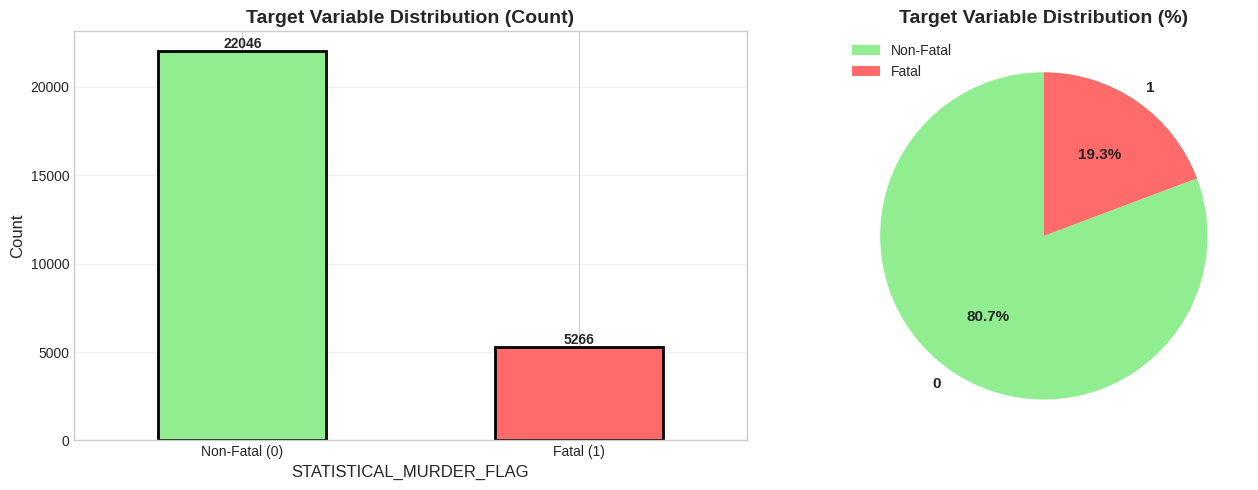

In [16]:
# =============================================================================
# 3.2 VISUALIZE TARGET DISTRIBUTION
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
df['STATISTICAL_MURDER_FLAG'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['#90EE90', '#FF6B6B'],
    edgecolor='black',
    linewidth=2
)
axes[0].set_title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('STATISTICAL_MURDER_FLAG', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Non-Fatal (0)', 'Fatal (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontweight='bold')

# Pie chart
colors = ['#90EE90', '#FF6B6B']
df['STATISTICAL_MURDER_FLAG'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Target Variable Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].legend(['Non-Fatal', 'Fatal'], loc='best')

plt.tight_layout()
plt.show()


4. Missing values and dropping sparse columns

4.1  – Detailed missing‑values table

In [17]:
# =============================================================================
# 4.1 MISSING VALUES ANALYSIS (AFTER TEMPORAL FILTER)
# =============================================================================

print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_df = (
    missing_df[missing_df['Missing_Count'] > 0]
    .sort_values(by='Missing_Percentage', ascending=False)
    .reset_index(drop=True)
)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print(" No missing values detected!")



MISSING VALUES ANALYSIS
            Column  Missing_Count  Missing_Percentage
 LOC_OF_OCCUR_DESC          25596              93.717
LOC_CLASSFCTN_DESC          25596              93.717
     LOCATION_DESC          14977              54.837
    PERP_AGE_GROUP           9344              34.212
         PERP_RACE           9310              34.088
          PERP_SEX           9310              34.088
         Longitude             10               0.037
          Latitude             10               0.037
           Lon_Lat             10               0.037
 JURISDICTION_CODE              2               0.007


4.2  – Visualise missingness

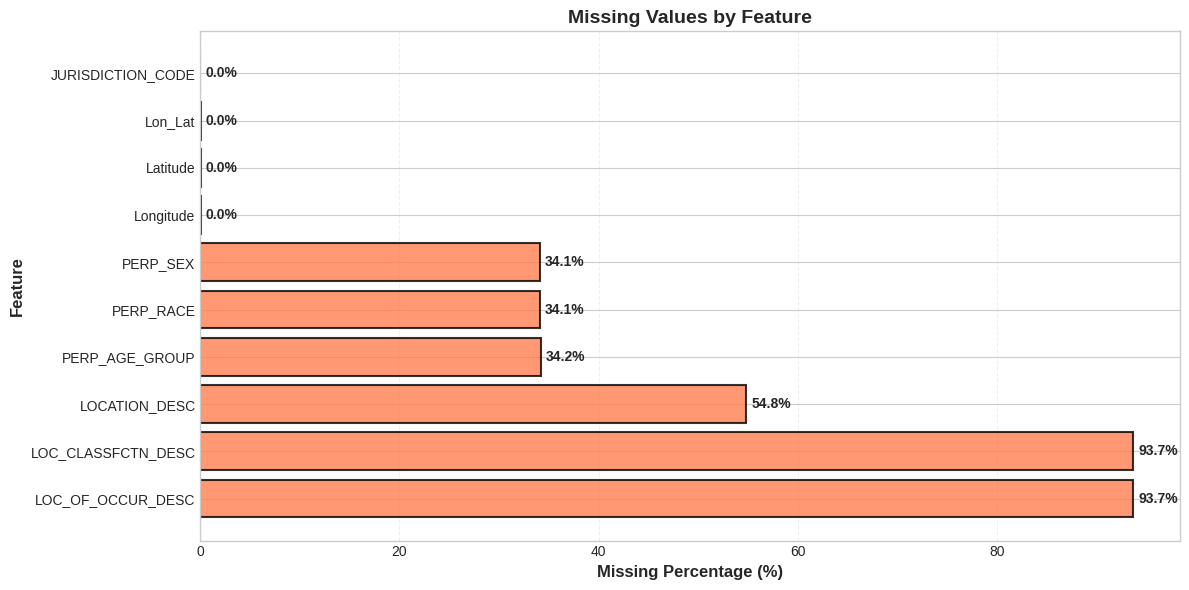

In [18]:
# =============================================================================
# 4.2 MISSING VALUES VISUALISATION
# =============================================================================

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.barh(
        missing_df['Column'],
        missing_df['Missing_Percentage'],
        color='coral',
        edgecolor='black',
        linewidth=1.5,
        alpha=0.8
    )
    ax.set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
    ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    for i, v in enumerate(missing_df['Missing_Percentage']):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center',
                fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(" No missing values to visualise!")


4.3  – Drop columns with very high missingness

In [19]:
# =============================================================================
# 4.3 DROP COLUMNS WITH HIGH MISSING VALUES
# =============================================================================

print("\n" + "=" * 80)
print("DROPPING COLUMNS WITH HIGH MISSING VALUES")
print("=" * 80)

print(f"\nDataset shape before dropping: {df.shape}")

# Columns to drop due to high missing values
high_missing_cols = [
    'LOC_OF_OCCUR_DESC',
    'LOC_CLASSFCTN_DESC',
    'LOCATION_DESC',
    'PERP_AGE_GROUP',
    'PERP_RACE',
    'PERP_SEX'
]

print("\nColumns being dropped and their missing percentages:")
for col in high_missing_cols:
    if col in df.columns:
        missing_pct = (df[col].isnull().sum() / len(df)) * 100
        print(f"  - {col:25s} : {missing_pct:6.2f}% missing")

# Drop the columns
df = df.drop(columns=high_missing_cols, axis=1)

print(f"\n {len(high_missing_cols)} columns dropped successfully")
print(f"Dataset shape after dropping: {df.shape}")

print("\nRemaining columns:")
print(df.columns.tolist())



DROPPING COLUMNS WITH HIGH MISSING VALUES

Dataset shape before dropping: (27312, 21)

Columns being dropped and their missing percentages:
  - LOC_OF_OCCUR_DESC         :  93.72% missing
  - LOC_CLASSFCTN_DESC        :  93.72% missing
  - LOCATION_DESC             :  54.84% missing
  - PERP_AGE_GROUP            :  34.21% missing
  - PERP_RACE                 :  34.09% missing
  - PERP_SEX                  :  34.09% missing

 6 columns dropped successfully
Dataset shape after dropping: (27312, 15)

Remaining columns:
['INCIDENT_KEY', 'OCCUR_DATE', 'OCCUR_TIME', 'BORO', 'PRECINCT', 'JURISDICTION_CODE', 'STATISTICAL_MURDER_FLAG', 'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Lon_Lat']


4.4  – Normalise string null markers and drop remaining rows with NA

In [20]:
# =============================================================================
# 4.4 NORMALISE STRING NULLS AND DROP REMAINING MISSING ROWS
# =============================================================================

import numpy as np

print("\n" + "=" * 80)
print("HANDLING REMAINING MISSING VALUES")
print("=" * 80)

print(f"Records before: {len(df):,}")

# String patterns that represent missing
missing_indicators = [
    '(null)', 'null', 'NULL', 'None', 'NONE', 'nan', 'NaN',
    'N/A', 'n/a', 'NA', 'unknown', 'UNKNOWN', '', ' ', 'U'
]

df = df.replace(missing_indicators, np.nan)

print("\nMissing values after converting string nulls:")
print(df.isnull().sum())

# Drop any rows that still contain missing values
df = df.dropna(how='any')

print(f"\nRecords after dropna: {len(df):,}")
print("All remaining rows are complete for the kept variables.")
print(df.isnull().sum())



HANDLING REMAINING MISSING VALUES
Records before: 27,312

Missing values after converting string nulls:
INCIDENT_KEY                0
OCCUR_DATE                  0
OCCUR_TIME                  0
BORO                        0
PRECINCT                    0
JURISDICTION_CODE           2
STATISTICAL_MURDER_FLAG     0
VIC_AGE_GROUP              61
VIC_SEX                    11
VIC_RACE                   66
X_COORD_CD                  0
Y_COORD_CD                  0
Latitude                   10
Longitude                  10
Lon_Lat                    10
dtype: int64

Records after dropna: 27,185
All remaining rows are complete for the kept variables.
INCIDENT_KEY               0
OCCUR_DATE                 0
OCCUR_TIME                 0
BORO                       0
PRECINCT                   0
JURISDICTION_CODE          0
STATISTICAL_MURDER_FLAG    0
VIC_AGE_GROUP              0
VIC_SEX                    0
VIC_RACE                   0
X_COORD_CD                 0
Y_COORD_CD                 

 5 – EDA of incidents over time and by borough/precinct,

5.1  – yearly incident counts and plot


SHOOTING INCIDENTS ACROSS YEARS (2006–2022)

Incidents by Year:
Year
2006    2048
2007    1874
2008    1952
2009    1817
2010    1908
2011    1928
2012    1706
2013    1332
2014    1450
2015    1426
2016    1200
2017     966
2018     955
2019     961
2020    1947
2021    2010
2022    1705
Name: count, dtype: int64

Total incidents: 27,185
Average per year: 1599
Highest: 2048 in 2006
Lowest: 955 in 2018


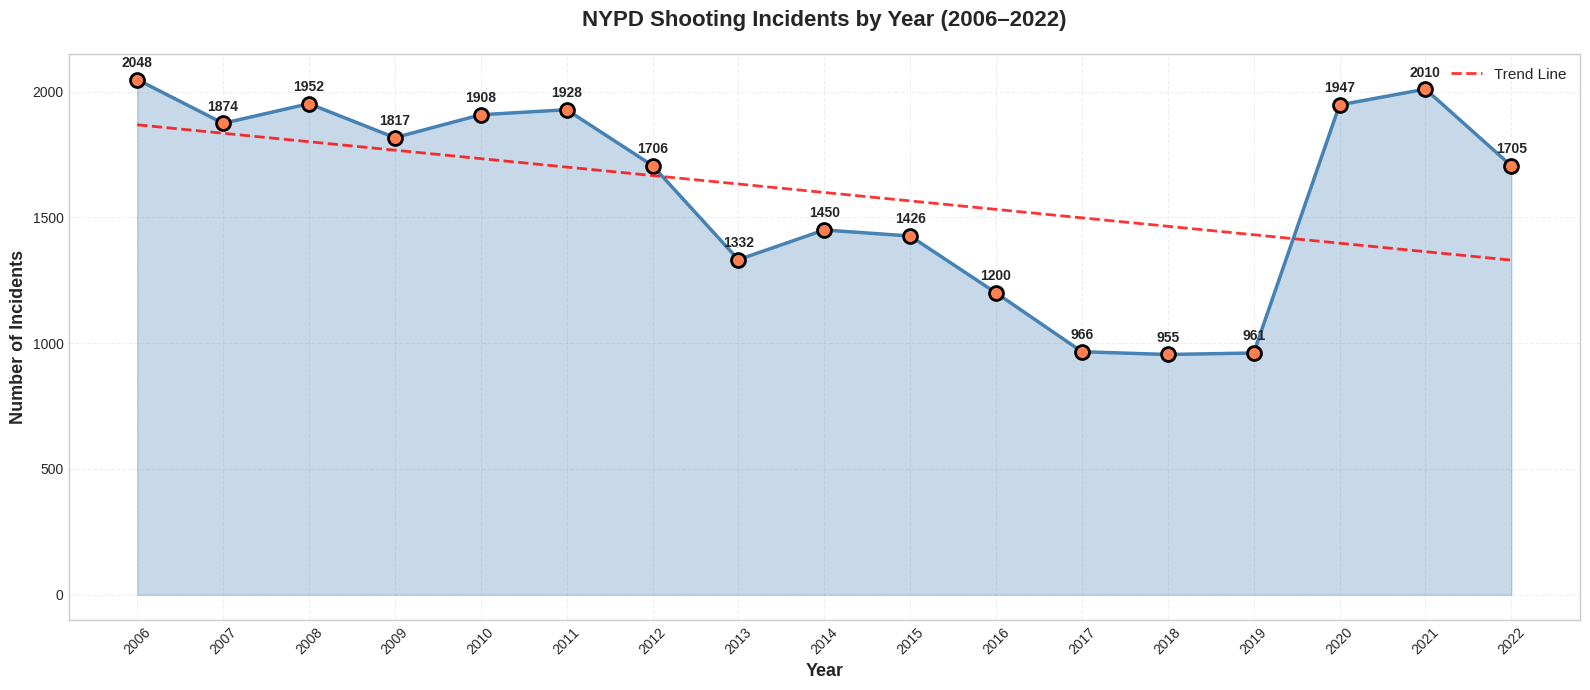

In [21]:
# =============================================================================
# 5.1 SHOOTING INCIDENTS ACROSS YEARS (2006–2022)
# =============================================================================

print("\n" + "=" * 80)
print("SHOOTING INCIDENTS ACROSS YEARS (2006–2022)")
print("=" * 80)

# Extract year from OCCUR_DATE
df['Year'] = df['OCCUR_DATE'].dt.year

# Count incidents by year
yearly_incidents = df['Year'].value_counts().sort_index()

print("\nIncidents by Year:")
print(yearly_incidents)

print(f"\nTotal incidents: {yearly_incidents.sum():,}")
print(f"Average per year: {yearly_incidents.mean():.0f}")
print(f"Highest: {yearly_incidents.max()} in {yearly_incidents.idxmax()}")
print(f"Lowest: {yearly_incidents.min()} in {yearly_incidents.idxmin()}")

# Plot
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    yearly_incidents.index,
    yearly_incidents.values,
    marker='o',
    linewidth=2.5,
    markersize=10,
    color='steelblue',
    markerfacecolor='coral',
    markeredgecolor='black',
    markeredgewidth=2
)

ax.fill_between(yearly_incidents.index,
                yearly_incidents.values,
                alpha=0.3,
                color='steelblue')

for year, count in zip(yearly_incidents.index, yearly_incidents.values):
    ax.text(year, count + 50, str(count),
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('NYPD Shooting Incidents by Year (2006–2022)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Incidents', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.set_xticks(yearly_incidents.index)
ax.tick_params(axis='x', rotation=45)

# Trend line
z = np.polyfit(yearly_incidents.index, yearly_incidents.values, 1)
p = np.poly1d(z)
ax.plot(yearly_incidents.index, p(yearly_incidents.index),
        "r--", alpha=0.8, linewidth=2, label='Trend Line')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


5.2 Incidents and fatality rate by borough

5.2.1 Code – borough table and plots


FATALITY RATE BY BOROUGH

Unique borough values:
['QUEENS' 'BROOKLYN' 'BRONX' 'MANHATTAN' 'STATEN ISLAND']

Borough fatality table:
               Fatal_Cases  Total_Cases  Fatality_Rate  Fatality_Rate_Pct
BORO                                                                     
STATEN ISLAND          162          773          0.210             20.957
QUEENS                 806         4070          0.198             19.803
BRONX                 1536         7902          0.194             19.438
BROOKLYN              2112        10882          0.194             19.408
MANHATTAN              628         3558          0.177             17.650


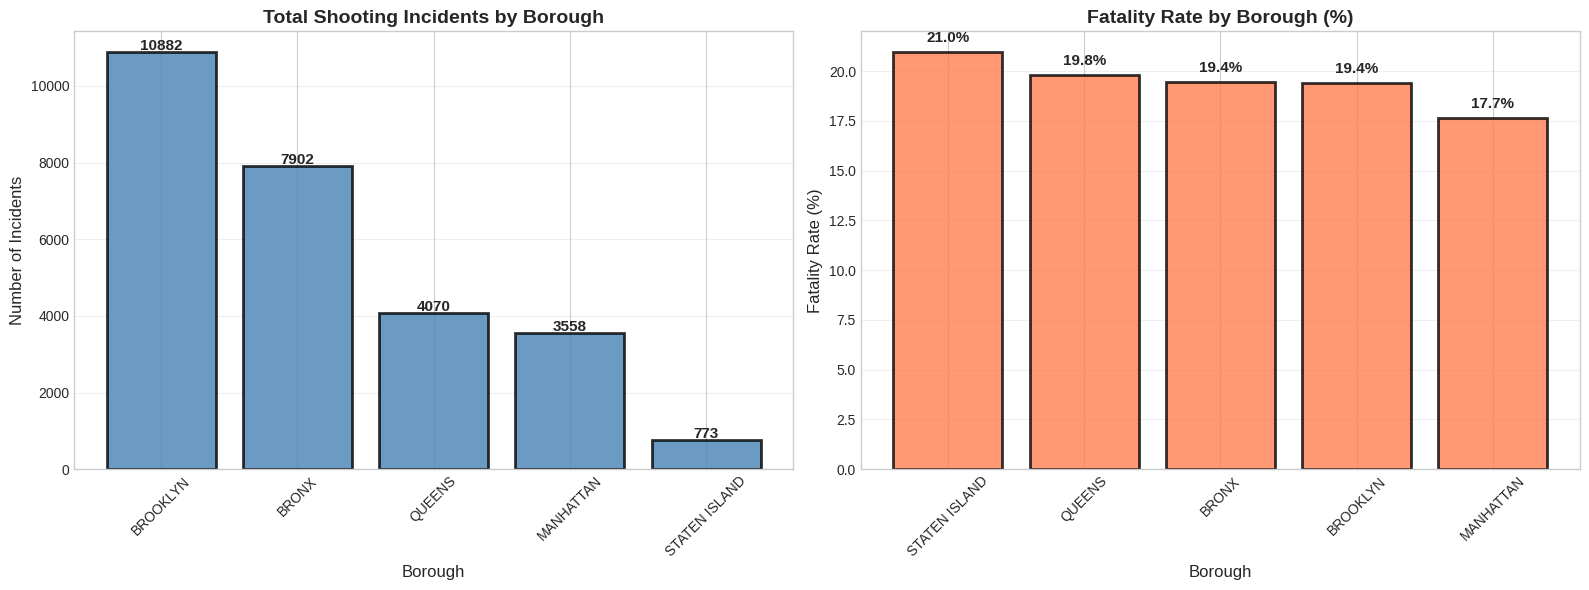

In [22]:
# =============================================================================
# 5.2 TARGET vs BOROUGH ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("FATALITY RATE BY BOROUGH")
print("=" * 80)

print("\nUnique borough values:")
print(df['BORO'].unique())

# Fatality rate by borough
boro_fatality = df.groupby('BORO')['STATISTICAL_MURDER_FLAG'].agg(['sum', 'count', 'mean'])
boro_fatality.columns = ['Fatal_Cases', 'Total_Cases', 'Fatality_Rate']
boro_fatality['Fatality_Rate_Pct'] = boro_fatality['Fatality_Rate'] * 100
boro_fatality = boro_fatality.sort_values('Fatality_Rate_Pct', ascending=False)

print("\nBorough fatality table:")
print(boro_fatality)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total incidents
boro_counts = df['BORO'].value_counts()
axes[0].bar(
    boro_counts.index,
    boro_counts.values,
    color='steelblue',
    edgecolor='black',
    linewidth=2,
    alpha=0.8
)
axes[0].set_title('Total Shooting Incidents by Borough',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Borough', fontsize=12)
axes[0].set_ylabel('Number of Incidents', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(boro_counts.values):
    axes[0].text(i, v + 50, str(v),
                 ha='center', fontsize=11, fontweight='bold')

# Fatality rate
axes[1].bar(
    boro_fatality.index,
    boro_fatality['Fatality_Rate_Pct'],
    color='coral',
    edgecolor='black',
    linewidth=2,
    alpha=0.8
)
axes[1].set_title('Fatality Rate by Borough (%)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Borough', fontsize=12)
axes[1].set_ylabel('Fatality Rate (%)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(boro_fatality['Fatality_Rate_Pct']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


5.3 Top precincts by incidents and fatality rate


5.3.1 Code – precinct table and plots


FATALITY RATE BY TOP 15 PRECINCTS
          Fatal_Cases  Total_Cases  Fatality_Rate  Fatality_Rate_Pct
PRECINCT                                                            
75                305         1548          0.197             19.703
73                271         1448          0.187             18.715
67                236         1213          0.195             19.456
44                193         1016          0.190             18.996
79                184         1004          0.183             18.327
47                207          949          0.218             21.812
40                160          906          0.177             17.660
46                183          891          0.205             20.539
42                164          847          0.194             19.362
81                151          798          0.189             18.922
113               151          798          0.189             18.922
77                169          790          0.214             21.392

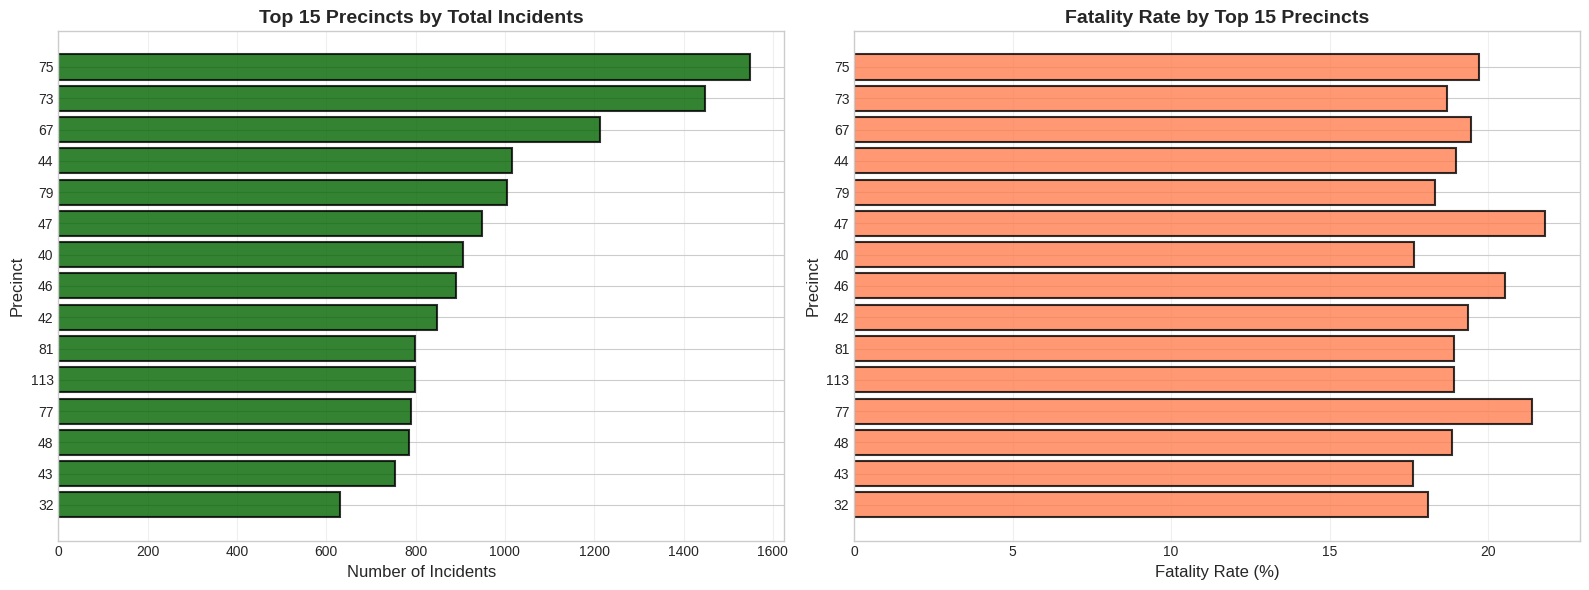

In [23]:
# =============================================================================
# 5.3 FATALITY RATE BY TOP 15 PRECINCTS
# =============================================================================

print("\n" + "=" * 80)
print("FATALITY RATE BY TOP 15 PRECINCTS")
print("=" * 80)

precinct_fatality = df.groupby('PRECINCT')['STATISTICAL_MURDER_FLAG'].agg(['sum', 'count', 'mean'])
precinct_fatality.columns = ['Fatal_Cases', 'Total_Cases', 'Fatality_Rate']
precinct_fatality['Fatality_Rate_Pct'] = precinct_fatality['Fatality_Rate'] * 100

top_precincts = precinct_fatality.nlargest(15, 'Total_Cases')
print(top_precincts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total incidents
axes[0].barh(
    range(len(top_precincts)),
    top_precincts['Total_Cases'],
    color='darkgreen',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)
axes[0].set_yticks(range(len(top_precincts)))
axes[0].set_yticklabels(top_precincts.index)
axes[0].set_title('Top 15 Precincts by Total Incidents',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Incidents', fontsize=12)
axes[0].set_ylabel('Precinct', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Fatality rate
axes[1].barh(
    range(len(top_precincts)),
    top_precincts['Fatality_Rate_Pct'],
    color='coral',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)
axes[1].set_yticks(range(len(top_precincts)))
axes[1].set_yticklabels(top_precincts.index)
axes[1].set_title('Fatality Rate by Top 15 Precincts',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fatality Rate (%)', fontsize=12)
axes[1].set_ylabel('Precinct', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


 6 – Temporal patterns within a day and temporal feature engineering (Hour, DayOfWeek, Month, IsWeekend, IsNightTime).

6.1  – Extract hour and analyse fatality by hour

In [24]:
# =============================================================================
# 6.1 TEMPORAL PATTERNS - TIME OF DAY ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print("TEMPORAL PATTERNS ANALYSIS")
print("=" * 80)

# Ensure OCCUR_TIME is parsed
df['OCCUR_TIME'] = pd.to_datetime(df['OCCUR_TIME'], format='%H:%M:%S').dt.time
df['Hour'] = pd.to_datetime(df['OCCUR_TIME'].astype(str), format='%H:%M:%S').dt.hour

# Fatality rate by hour
hour_fatality = df.groupby('Hour')['STATISTICAL_MURDER_FLAG'].agg(['sum', 'count', 'mean'])
hour_fatality.columns = ['Fatal_Cases', 'Total_Cases', 'Fatality_Rate']
hour_fatality['Fatality_Rate_Pct'] = hour_fatality['Fatality_Rate'] * 100

print("\nFatality Rate by Hour of Day:")
print(hour_fatality)



TEMPORAL PATTERNS ANALYSIS

Fatality Rate by Hour of Day:
      Fatal_Cases  Total_Cases  Fatality_Rate  Fatality_Rate_Pct
Hour                                                            
0             392         2175          0.180             18.023
1             363         2070          0.175             17.536
2             312         1805          0.173             17.285
3             282         1627          0.173             17.333
4             293         1439          0.204             20.361
5             173          700          0.247             24.714
6              87          363          0.240             23.967
7              71          233          0.305             30.472
8              63          234          0.269             26.923
9              51          217          0.235             23.502
10             70          302          0.232             23.179
11             92          370          0.249             24.865
12            111          486 

6.2  – Plots: incidents and fatality rate by hour

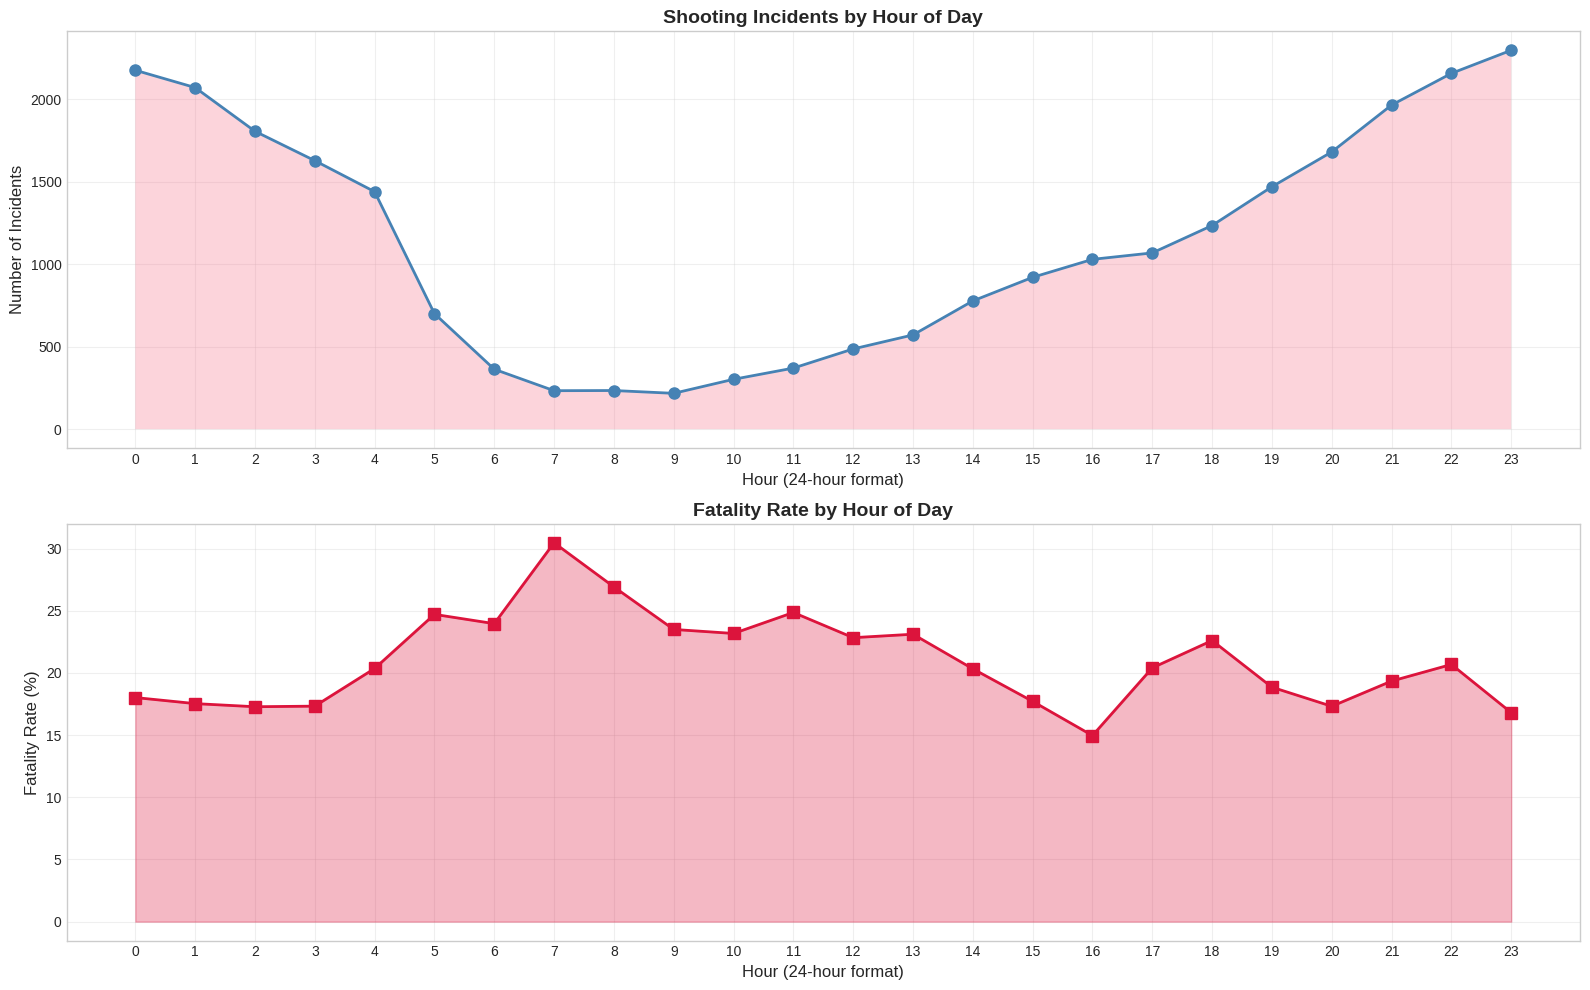

In [25]:
# =============================================================================
# 6.2 VISUALISE TIME-OF-DAY PATTERNS
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Incidents by hour
axes[0].plot(
    hour_fatality.index,
    hour_fatality['Total_Cases'],
    marker='o',
    linewidth=2,
    markersize=8,
    color='steelblue'
)
axes[0].fill_between(hour_fatality.index,
                     hour_fatality['Total_Cases'],
                     alpha=0.3)
axes[0].set_title('Shooting Incidents by Hour of Day',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour (24-hour format)', fontsize=12)
axes[0].set_ylabel('Number of Incidents', fontsize=12)
axes[0].set_xticks(range(0, 24))
axes[0].grid(alpha=0.3)

# Fatality rate by hour
axes[1].plot(
    hour_fatality.index,
    hour_fatality['Fatality_Rate_Pct'],
    marker='s',
    linewidth=2,
    markersize=8,
    color='crimson'
)
axes[1].fill_between(hour_fatality.index,
                     hour_fatality['Fatality_Rate_Pct'],
                     alpha=0.3,
                     color='crimson')
axes[1].set_title('Fatality Rate by Hour of Day',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour (24-hour format)', fontsize=12)
axes[1].set_ylabel('Fatality Rate (%)', fontsize=12)
axes[1].set_xticks(range(0, 24))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


6.3  – Create temporal features (DayOfWeek, Month, IsWeekend, IsNightTime)

In [26]:
# =============================================================================
# 6.3 TEMPORAL FEATURE ENGINEERING
# =============================================================================

print("\n" + "=" * 80)
print("CREATING TEMPORAL FEATURES")
print("=" * 80)

# Day of week and month
df['DayOfWeek'] = df['OCCUR_DATE'].dt.dayofweek   # 0=Mon, 6=Sun
df['Month'] = df['OCCUR_DATE'].dt.month           # 1–12

# Derived binary flags
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)     # Sat/Sun
df['IsNightTime'] = ((df['Hour'] >= 20) | (df['Hour'] < 6)).astype(int)  # 20:00–06:00

print(" Temporal features created:")
print(f"  - Hour: {df['Hour'].min()} to {df['Hour'].max()}")
print(f"  - DayOfWeek: {df['DayOfWeek'].min()} to {df['DayOfWeek'].max()} (0=Mon, 6=Sun)")
print(f"  - Month: {df['Month'].min()} to {df['Month'].max()}")
print(f"  - IsWeekend distribution: {df['IsWeekend'].value_counts().to_dict()}")
print(f"  - IsNightTime distribution: {df['IsNightTime'].value_counts().to_dict()}")



CREATING TEMPORAL FEATURES
 Temporal features created:
  - Hour: 0 to 23
  - DayOfWeek: 0 to 6 (0=Mon, 6=Sun)
  - Month: 1 to 12
  - IsWeekend distribution: {0: 16583, 1: 10602}
  - IsNightTime distribution: {1: 17912, 0: 9273}


 7 – Victim demographics and categorical encoding,

7.1  – basic distributions for VIC_AGE_GROUP, VIC_SEX, VIC_RACE

In [27]:
# =============================================================================
# 7.1 VICTIM DEMOGRAPHIC DISTRIBUTIONS
# =============================================================================

print("\n" + "=" * 80)
print("VICTIM DEMOGRAPHIC SUMMARY")
print("=" * 80)

for col in ['VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().sort_index())
    print("-" * 60)



VICTIM DEMOGRAPHIC SUMMARY

Column: VIC_AGE_GROUP
VIC_AGE_GROUP
1022         1
18-24    10056
25-44    12254
45-64     1858
65+        181
<18       2835
Name: count, dtype: int64
------------------------------------------------------------

Column: VIC_SEX
VIC_SEX
F     2607
M    24578
Name: count, dtype: int64
------------------------------------------------------------

Column: VIC_RACE
VIC_RACE
AMERICAN INDIAN/ALASKAN NATIVE       10
ASIAN / PACIFIC ISLANDER            403
BLACK                             19410
BLACK HISPANIC                     2640
WHITE                               684
WHITE HISPANIC                     4038
Name: count, dtype: int64
------------------------------------------------------------


7.2  – label‑encode victim and borough categories

In [28]:
# =============================================================================
# 7.2 ENCODING CATEGORICAL FEATURES (BORO + VICTIM DEMOGRAPHICS)
# =============================================================================

from sklearn.preprocessing import LabelEncoder

print("\n" + "=" * 80)
print("ENCODING CATEGORICAL FEATURES")
print("=" * 80)

# Encode BORO
le_boro = LabelEncoder()
df['BORO_ENCODED'] = le_boro.fit_transform(df['BORO'])
print(f"\n BORO encoded: {dict(zip(le_boro.classes_, le_boro.transform(le_boro.classes_)))}")

# Encode VIC_AGE_GROUP
le_age = LabelEncoder()
df['VIC_AGE_ENCODED'] = le_age.fit_transform(df['VIC_AGE_GROUP'])
print(f" VIC_AGE_GROUP encoded: {dict(zip(le_age.classes_, le_age.transform(le_age.classes_)))}")

# Encode VIC_SEX
le_sex = LabelEncoder()
df['VIC_SEX_ENCODED'] = le_sex.fit_transform(df['VIC_SEX'])
print(f" VIC_SEX encoded: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

# Encode VIC_RACE
le_race = LabelEncoder()
df['VIC_RACE_ENCODED'] = le_race.fit_transform(df['VIC_RACE'])
print(f" VIC_RACE encoded: {dict(zip(le_race.classes_, le_race.transform(le_race.classes_)))}")

print("\n All categorical victim and borough features encoded successfully.")



ENCODING CATEGORICAL FEATURES

 BORO encoded: {'BRONX': np.int64(0), 'BROOKLYN': np.int64(1), 'MANHATTAN': np.int64(2), 'QUEENS': np.int64(3), 'STATEN ISLAND': np.int64(4)}
 VIC_AGE_GROUP encoded: {'1022': np.int64(0), '18-24': np.int64(1), '25-44': np.int64(2), '45-64': np.int64(3), '65+': np.int64(4), '<18': np.int64(5)}
 VIC_SEX encoded: {'F': np.int64(0), 'M': np.int64(1)}
 VIC_RACE encoded: {'AMERICAN INDIAN/ALASKAN NATIVE': np.int64(0), 'ASIAN / PACIFIC ISLANDER': np.int64(1), 'BLACK': np.int64(2), 'BLACK HISPANIC': np.int64(3), 'WHITE': np.int64(4), 'WHITE HISPANIC': np.int64(5)}

 All categorical victim and borough features encoded successfully.


8. Spatial patterns, correlation, and outliers

8.1 Geographic scatter: where do shootings happen?


GEOGRAPHIC ANALYSIS - SHOOTING HOTSPOTS


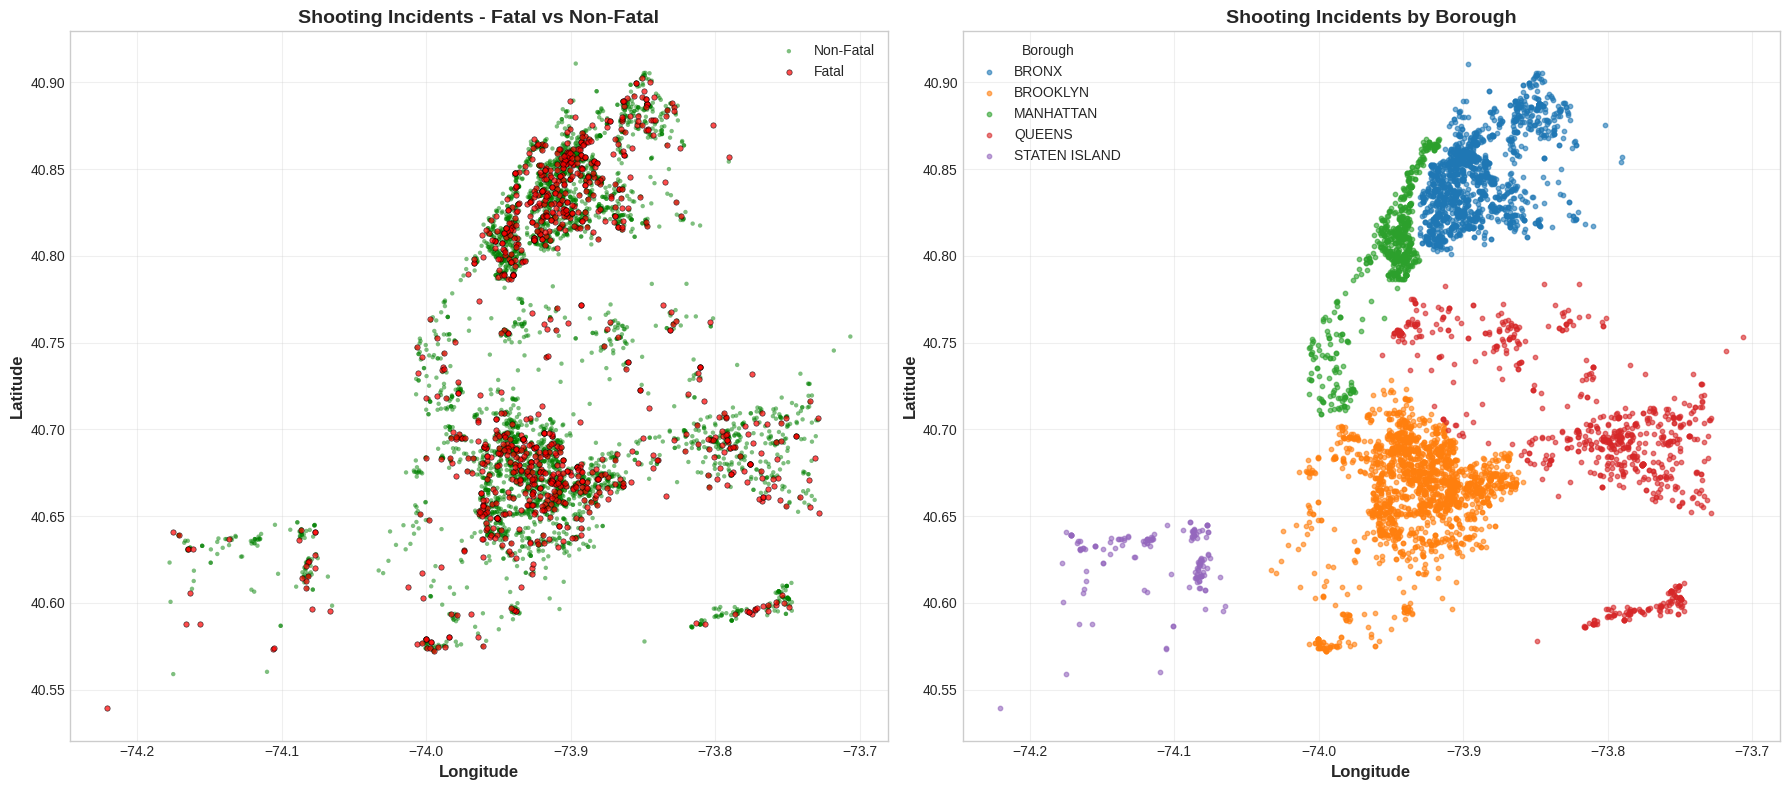


 Plotted 5,000 sample incidents.
  Fatal: 968 (19.4%)
  Non-Fatal: 4,032 (80.6%)


In [29]:
# =============================================================================
# 8.1 GEOGRAPHIC ANALYSIS - SHOOTING HOTSPOTS
# =============================================================================

print("\n" + "=" * 80)
print("GEOGRAPHIC ANALYSIS - SHOOTING HOTSPOTS")
print("=" * 80)

# Sample for plotting (for performance)
df_sample = df.sample(n=min(5000, len(df)), random_state=42)

fatal = df_sample[df_sample['STATISTICAL_MURDER_FLAG'] == 1]
non_fatal = df_sample[df_sample['STATISTICAL_MURDER_FLAG'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Fatal vs non-fatal
axes[0].scatter(
    non_fatal['Longitude'], non_fatal['Latitude'],
    c='green', alpha=0.5, s=10, label='Non-Fatal', edgecolors='none'
)
axes[0].scatter(
    fatal['Longitude'], fatal['Latitude'],
    c='red', alpha=0.7, s=15, label='Fatal',
    edgecolors='black', linewidths=0.5
)
axes[0].set_title('Shooting Incidents - Fatal vs Non-Fatal',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Latitude', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# By borough (using encoded BORO_ENCODED)
boro_names = {i: c for i, c in enumerate(le_boro.classes_)}  # from earlier encoder
colors_boro = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, boro in enumerate(sorted(df_sample['BORO_ENCODED'].unique())):
    boro_data = df_sample[df_sample['BORO_ENCODED'] == boro]
    axes[1].scatter(
        boro_data['Longitude'], boro_data['Latitude'],
        label=boro_names.get(boro, f'Borough {boro}'),
        alpha=0.6, s=10, color=colors_boro[i]
    )

axes[1].set_title('Shooting Incidents by Borough',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Latitude', fontsize=12, fontweight='bold')
axes[1].legend(title='Borough', loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Plotted {len(df_sample):,} sample incidents.")
print(f"  Fatal: {len(fatal):,} ({len(fatal)/len(df_sample)*100:.1f}%)")
print(f"  Non-Fatal: {len(non_fatal):,} ({len(non_fatal)/len(df_sample)*100:.1f}%)")


8.2 Correlation of numeric features with the target


CORRELATION ANALYSIS

Correlation with target (STATISTICAL_MURDER_FLAG):
STATISTICAL_MURDER_FLAG    1.000
VIC_RACE_ENCODED           0.019
PRECINCT                   0.012
Month                      0.005
Longitude                  0.001
X_COORD_CD                 0.001
Hour                       0.001
INCIDENT_KEY               0.001
BORO_ENCODED               0.001
Y_COORD_CD                -0.007
Latitude                  -0.007
DayOfWeek                 -0.008
VIC_SEX_ENCODED           -0.009
VIC_AGE_ENCODED           -0.010
IsWeekend                 -0.015
IsNightTime               -0.027
JURISDICTION_CODE         -0.035
Name: STATISTICAL_MURDER_FLAG, dtype: float64


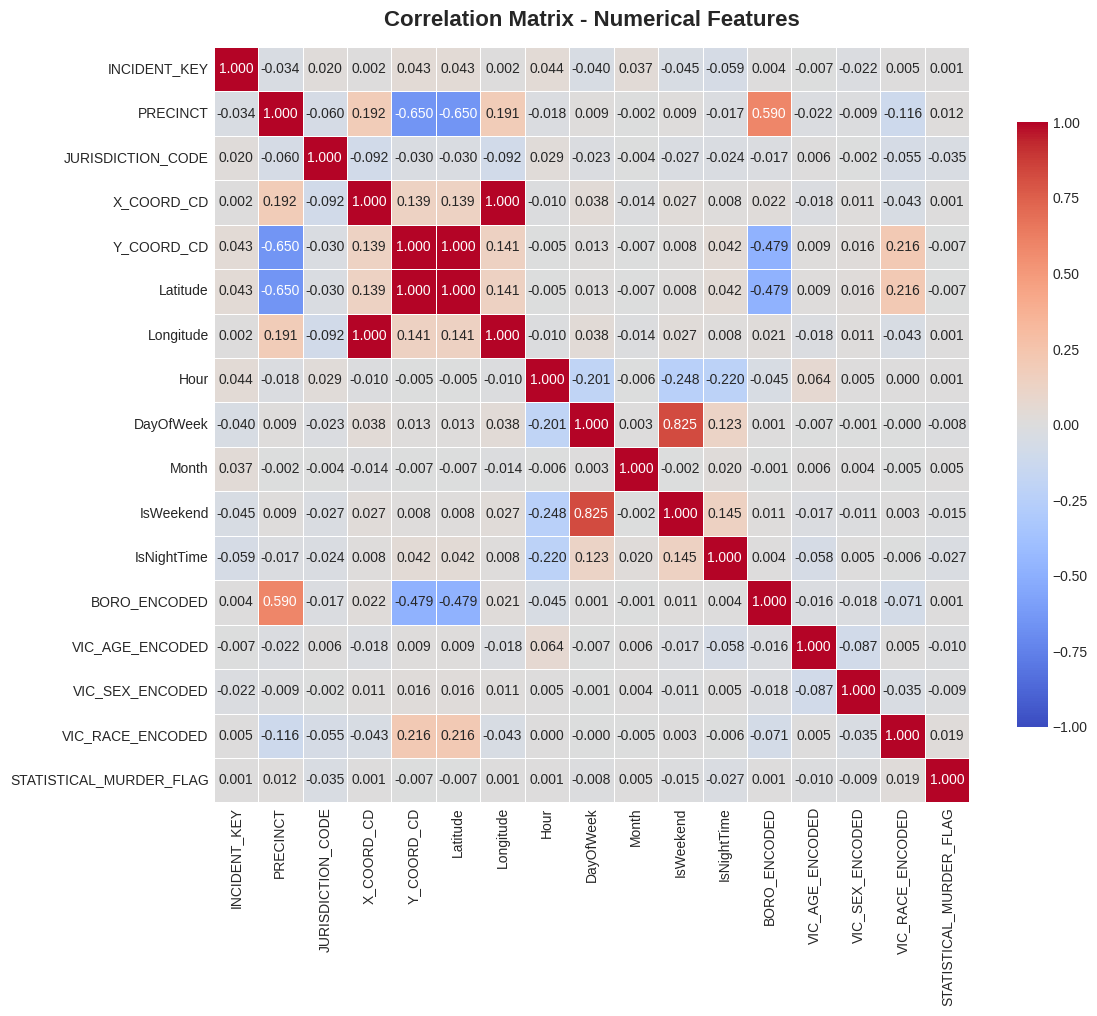

In [30]:
# =============================================================================
# 8.2 CORRELATION ANALYSIS - NUMERICAL FEATURES
# =============================================================================

print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

numerical_features = [
    'INCIDENT_KEY', 'PRECINCT', 'JURISDICTION_CODE',
    'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude',
    'Hour', 'DayOfWeek', 'Month',
    'IsWeekend', 'IsNightTime',
    'BORO_ENCODED', 'VIC_AGE_ENCODED',
    'VIC_SEX_ENCODED', 'VIC_RACE_ENCODED',
    'STATISTICAL_MURDER_FLAG'
]

numerical_features = [c for c in numerical_features if c in df.columns]
df_num = df[numerical_features].copy()

corr = df_num.corr()

print("\nCorrelation with target (STATISTICAL_MURDER_FLAG):")
print(corr['STATISTICAL_MURDER_FLAG'].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    center=0, vmin=-1, vmax=1, ax=ax
)
ax.set_title('Correlation Matrix - Numerical Features',
             fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


8.3 Outlier detection and decision


OUTLIER DETECTION ANALYSIS & COLUMNS DATA UNDERSTANDING


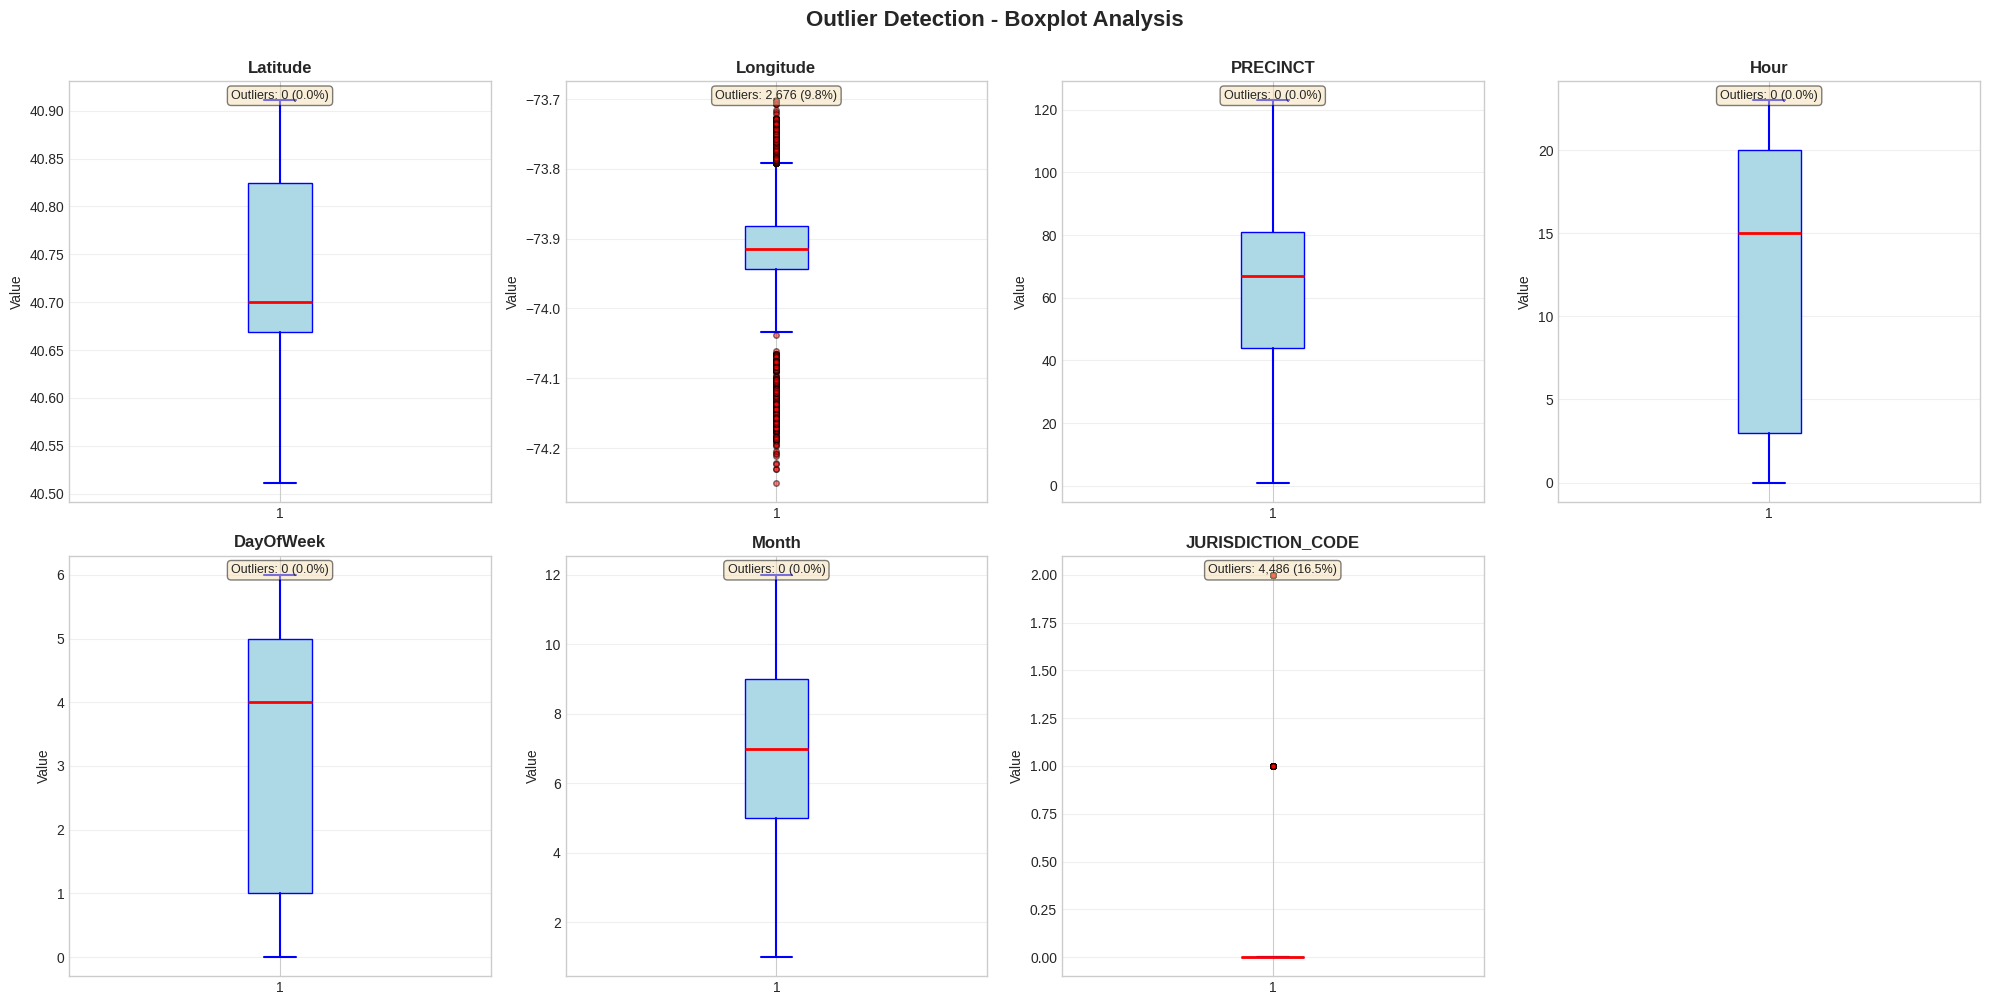


Outlier percentages by feature:
          Feature  Outlier_Pct
         Latitude        0.000
        Longitude        9.844
         PRECINCT        0.000
             Hour        0.000
        DayOfWeek        0.000
            Month        0.000
JURISDICTION_CODE       16.502


In [31]:
# =============================================================================
# 8.3 OUTLIER DETECTION - NUMERICAL FEATURES
# =============================================================================

print("\n" + "=" * 80)
print("OUTLIER DETECTION ANALYSIS & COLUMNS DATA UNDERSTANDING")
print("=" * 80)

num_for_outliers = ['Latitude', 'Longitude', 'PRECINCT', 'Hour',
                    'DayOfWeek', 'Month', 'JURISDICTION_CODE']

num_for_outliers = [c for c in num_for_outliers if c in df.columns]

# 8.3.1 Boxplots with outlier stats
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

outlier_stats = []

for i, col in enumerate(num_for_outliers):
    bp = axes[i].boxplot(
        df[col], vert=True, patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='blue'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='blue', linewidth=1.5),
        capprops=dict(color='blue', linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='red',
                        markersize=4, alpha=0.5)
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_pct = len(outliers) / len(df) * 100

    axes[i].text(
        0.5, 0.98,
        f'Outliers: {len(outliers):,} ({outlier_pct:.1f}%)',
        transform=axes[i].transAxes, ha='center', va='top',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

    outlier_stats.append({
        'Feature': col,
        'Outlier_Pct': outlier_pct
    })

# hide extra subplot if needed
for j in range(len(num_for_outliers), len(axes)):
    axes[j].axis('off')

plt.suptitle('Outlier Detection - Boxplot Analysis',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_stats)
print("\nOutlier percentages by feature:")
print(outlier_df.to_string(index=False))




Outliers:

Outlier analysis shows no statistical outliers in Latitude, PRECINCT, Hour, DayOfWeek, or Month, and about 9.8% of records flagged as outliers in Longitude and 16.5% in JURISDICTION_CODE under a strict IQR rule.
​

These “outliers” are still within the legitimate range for NYC geography and NYPD jurisdiction codes (0, 1, 2 – patrol, transit, housing), so they represent real but less common locations and jurisdiction contexts rather than data errors

9: FINAL DATASET PREPARATION

In [32]:
# ============================================================================
# 9. FINAL DATASET PREPARATION
# ============================================================================

print("="*80)
print("9. FINAL DATASET PREPARATION")
print("="*80)

# %%
# 9.1 Define Feature Sets
print("\n9.1 DEFINING FEATURE SETS...")

# Full features (13)
full_features = [
    'PRECINCT', 'JURISDICTION_CODE',
    'Latitude', 'Longitude', 'BORO_ENCODED',
    'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsNightTime',
    'VIC_AGE_ENCODED', 'VIC_SEX_ENCODED', 'VIC_RACE_ENCODED'
]

# Simple features 02 (5) - Lat, Long, Hour, Month, PRECINCT
simple_features_02 = ['Longitude', 'Latitude', 'Hour', 'Month', 'PRECINCT']

# Simple features 04 (4) - Lat, Long, Hour, Month (no PRECINCT)
simple_features_04 = ['Longitude', 'Latitude', 'Hour', 'Month']

# Target
target_col = 'STATISTICAL_MURDER_FLAG'

# %%
# 9.2 Verify Features Exist in DataFrame
full_features = [col for col in full_features if col in df.columns]
simple_features_02 = [col for col in simple_features_02 if col in df.columns]
simple_features_04 = [col for col in simple_features_04 if col in df.columns]

print(f"\n Full Features ({len(full_features)}):")
for col in full_features:
    print(f"   - {col}")

print(f"\n Simple Features 02 ({len(simple_features_02)}):")
for col in simple_features_02:
    print(f"   - {col}")

print(f"\n Simple Features 04 ({len(simple_features_04)}):")
for col in simple_features_04:
    print(f"   - {col}")

# %%
# 9.3 Create Feature & Target Arrays
print("\n9.3 CREATING DATASETS...")

X_full = df[full_features].copy()
X_simple_02 = df[simple_features_02].copy()
X_simple_04 = df[simple_features_04].copy()
y = df[target_col].copy()

print(f"\n X_full: {X_full.shape}")
print(f" X_simple_02: {X_simple_02.shape}")
print(f" X_simple_04: {X_simple_04.shape}")
print(f" y (target): {y.shape}")
print(f"\n Total records: {len(df):,}")


9. FINAL DATASET PREPARATION

9.1 DEFINING FEATURE SETS...

 Full Features (13):
   - PRECINCT
   - JURISDICTION_CODE
   - Latitude
   - Longitude
   - BORO_ENCODED
   - Hour
   - DayOfWeek
   - Month
   - IsWeekend
   - IsNightTime
   - VIC_AGE_ENCODED
   - VIC_SEX_ENCODED
   - VIC_RACE_ENCODED

 Simple Features 02 (5):
   - Longitude
   - Latitude
   - Hour
   - Month
   - PRECINCT

 Simple Features 04 (4):
   - Longitude
   - Latitude
   - Hour
   - Month

9.3 CREATING DATASETS...

 X_full: (27185, 13)
 X_simple_02: (27185, 5)
 X_simple_04: (27185, 4)
 y (target): (27185,)

 Total records: 27,185


10: TRAIN-TEST SPLIT & PREPROCESSING

In [33]:
# ============================================================================
# 10. TRAIN-TEST SPLIT & PREPROCESSING
# ============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print("\n" + "="*80)
print("10. TRAIN-TEST SPLIT & PREPROCESSING")
print("="*80)

# %%
# 10.1 Train-Test Split (80-20)
print("\n10.1 TRAIN-TEST SPLIT (80-20)...")

# Split full features
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Split simple_02
X_train_s02, X_test_s02 = train_test_split(
    X_simple_02, test_size=0.2, random_state=42, stratify=y
)[0:2]

# Split simple_04
X_train_s04, X_test_s04 = train_test_split(
    X_simple_04, test_size=0.2, random_state=42, stratify=y
)[0:2]

print(f"✓ Training set: {len(X_train_full):,} samples (80%)")
print(f"✓ Test set: {len(X_test_full):,} samples (20%)")
print(f"✓ Train target: Class 0={( y_train==0).sum():,}, Class 1={(y_train==1).sum():,}")
print(f"✓ Test target: Class 0={(y_test==0).sum():,}, Class 1={(y_test==1).sum():,}")

# %%
# 10.2 Feature Scaling
print("\n10.2 FEATURE SCALING (StandardScaler)...")

# Scale full features
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

# Scale simple_02
scaler_s02 = StandardScaler()
X_train_s02_scaled = scaler_s02.fit_transform(X_train_s02)
X_test_s02_scaled = scaler_s02.transform(X_test_s02)

# Scale simple_04
scaler_s04 = StandardScaler()
X_train_s04_scaled = scaler_s04.fit_transform(X_train_s04)
X_test_s04_scaled = scaler_s04.transform(X_test_s04)

print(" Full features scaled")
print(" Simple_02 features scaled")
print(" Simple_04 features scaled")

# %%
# 10.3 SMOTE Balancing
print("\n10.3 SMOTE BALANCING...")

smote = SMOTE(random_state=42)

print(f"Before SMOTE: {len(y_train):,} samples")
print(f"  Class 0: {(y_train==0).sum():,}")
print(f"  Class 1: {(y_train==1).sum():,}")

# SMOTE for full features
X_train_full_smote, y_train_smote = smote.fit_resample(X_train_full_scaled, y_train)

# SMOTE for simple_02
X_train_s02_smote, y_train_s02_smote = smote.fit_resample(X_train_s02_scaled, y_train)

# SMOTE for simple_04
X_train_s04_smote, y_train_s04_smote = smote.fit_resample(X_train_s04_scaled, y_train)

print(f"\nAfter SMOTE: {len(y_train_smote):,} samples")
print(f"  Class 0: {(y_train_smote==0).sum():,}")
print(f"  Class 1: {(y_train_smote==1).sum():,}")
print("\n All datasets balanced with SMOTE")



10. TRAIN-TEST SPLIT & PREPROCESSING

10.1 TRAIN-TEST SPLIT (80-20)...
✓ Training set: 21,748 samples (80%)
✓ Test set: 5,437 samples (20%)
✓ Train target: Class 0=17,553, Class 1=4,195
✓ Test target: Class 0=4,388, Class 1=1,049

10.2 FEATURE SCALING (StandardScaler)...
 Full features scaled
 Simple_02 features scaled
 Simple_04 features scaled

10.3 SMOTE BALANCING...
Before SMOTE: 21,748 samples
  Class 0: 17,553
  Class 1: 4,195

After SMOTE: 35,106 samples
  Class 0: 17,553
  Class 1: 17,553

 All datasets balanced with SMOTE


 11: EXPERIMENT 1 - FULL FEATURES + SMOTE


11. EXPERIMENT 1: FULL FEATURES (13) + SMOTE
Features: ['PRECINCT', 'JURISDICTION_CODE', 'Latitude', 'Longitude', 'BORO_ENCODED', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsNightTime', 'VIC_AGE_ENCODED', 'VIC_SEX_ENCODED', 'VIC_RACE_ENCODED']
Training: 35,106 samples (with SMOTE)
Testing: 5,437 samples

--------------------------------------------------------------------------------
11.1 LOGISTIC REGRESSION (Full + SMOTE)
--------------------------------------------------------------------------------

Confusion Matrix:
[[1976 2412]
 [ 411  638]]

Classification Report:
              precision    recall  f1-score   support

           0      0.828     0.450     0.583      4388
           1      0.209     0.608     0.311      1049

    accuracy                          0.481      5437
   macro avg      0.518     0.529     0.447      5437
weighted avg      0.708     0.481     0.531      5437

ROC-AUC: 0.535

----------------------------------------------------------------------------

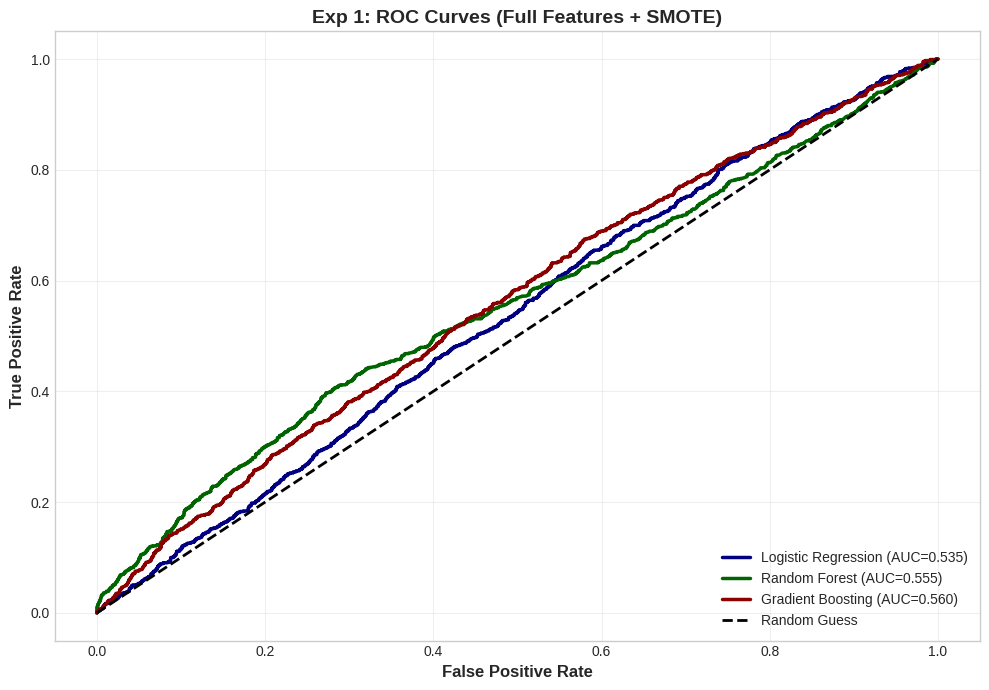


 Experiment 1 Complete


In [34]:
# ============================================================================
# 11. EXPERIMENT 1: FULL FEATURES (13) + SMOTE
# ============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve)

print("\n" + "="*80)
print("11. EXPERIMENT 1: FULL FEATURES (13) + SMOTE")
print("="*80)
print(f"Features: {full_features}")
print(f"Training: {len(X_train_full_smote):,} samples (with SMOTE)")
print(f"Testing: {len(X_test_full):,} samples")

results_exp1 = {}

# %%
# 11.1 Logistic Regression
print("\n" + "-"*80)
print("11.1 LOGISTIC REGRESSION (Full + SMOTE)")
print("-"*80)

lr_exp1 = LogisticRegression(max_iter=1000, random_state=42)
lr_exp1.fit(X_train_full_smote, y_train_smote)

y_pred_lr1 = lr_exp1.predict(X_test_full_scaled)
y_proba_lr1 = lr_exp1.predict_proba(X_test_full_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr1))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr1, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr1):.3f}")

results_exp1['Logistic Regression'] = {
    'model': lr_exp1,
    'y_pred': y_pred_lr1,
    'y_proba': y_proba_lr1,
    'accuracy': accuracy_score(y_test, y_pred_lr1),
    'precision': precision_score(y_test, y_pred_lr1),
    'recall': recall_score(y_test, y_pred_lr1),
    'f1': f1_score(y_test, y_pred_lr1),
    'auc': roc_auc_score(y_test, y_proba_lr1)
}

# %%
# 11.2 Random Forest
print("\n" + "-"*80)
print("11.2 RANDOM FOREST (Full + SMOTE)")
print("-"*80)

rf_exp1 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_exp1.fit(X_train_full_smote, y_train_smote)

y_pred_rf1 = rf_exp1.predict(X_test_full_scaled)
y_proba_rf1 = rf_exp1.predict_proba(X_test_full_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf1))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf1, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf1):.3f}")

results_exp1['Random Forest'] = {
    'model': rf_exp1,
    'y_pred': y_pred_rf1,
    'y_proba': y_proba_rf1,
    'accuracy': accuracy_score(y_test, y_pred_rf1),
    'precision': precision_score(y_test, y_pred_rf1),
    'recall': recall_score(y_test, y_pred_rf1),
    'f1': f1_score(y_test, y_pred_rf1),
    'auc': roc_auc_score(y_test, y_proba_rf1)
}

# %%
# 11.3 Gradient Boosting
print("\n" + "-"*80)
print("11.3 GRADIENT BOOSTING (Full + SMOTE)")
print("-"*80)

gb_exp1 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_exp1.fit(X_train_full_smote, y_train_smote)

y_pred_gb1 = gb_exp1.predict(X_test_full_scaled)
y_proba_gb1 = gb_exp1.predict_proba(X_test_full_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb1))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb1, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb1):.3f}")

results_exp1['Gradient Boosting'] = {
    'model': gb_exp1,
    'y_pred': y_pred_gb1,
    'y_proba': y_proba_gb1,
    'accuracy': accuracy_score(y_test, y_pred_gb1),
    'precision': precision_score(y_test, y_pred_gb1),
    'recall': recall_score(y_test, y_pred_gb1),
    'f1': f1_score(y_test, y_pred_gb1),
    'auc': roc_auc_score(y_test, y_proba_gb1)
}

# %%
# 11.4 ROC Curves Comparison
print("\n" + "-"*80)
print("11.4 ROC CURVES - EXPERIMENT 1")
print("-"*80)

plt.figure(figsize=(10, 7))

colors = {
    'Logistic Regression': 'navy',
    'Random Forest': 'darkgreen',
    'Gradient Boosting': 'darkred'
}

for model_name, res in results_exp1.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr,
             label=f"{model_name} (AUC={res['auc']:.3f})",
             color=colors[model_name],
             linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Exp 1: ROC Curves (Full Features + SMOTE)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Experiment 1 Complete")


EXPERIMENT 2: SIMPLE FEATURES (5) + SMOTE


12. EXPERIMENT 2: SIMPLE FEATURES (5) + SMOTE
Features: ['Longitude', 'Latitude', 'Hour', 'Month', 'PRECINCT']
Training: 35,106 samples (with SMOTE)
Testing: 5,437 samples

--------------------------------------------------------------------------------
12.1 LOGISTIC REGRESSION (Simple_02 + SMOTE)
--------------------------------------------------------------------------------

Confusion Matrix:
[[2286 2102]
 [ 551  498]]

Classification Report:
              precision    recall  f1-score   support

           0      0.806     0.521     0.633      4388
           1      0.192     0.475     0.273      1049

    accuracy                          0.512      5437
   macro avg      0.499     0.498     0.453      5437
weighted avg      0.687     0.512     0.563      5437

ROC-AUC: 0.500

--------------------------------------------------------------------------------
12.2 RANDOM FOREST (Simple_02 + SMOTE)
--------------------------------------------------------------------------------

Conf

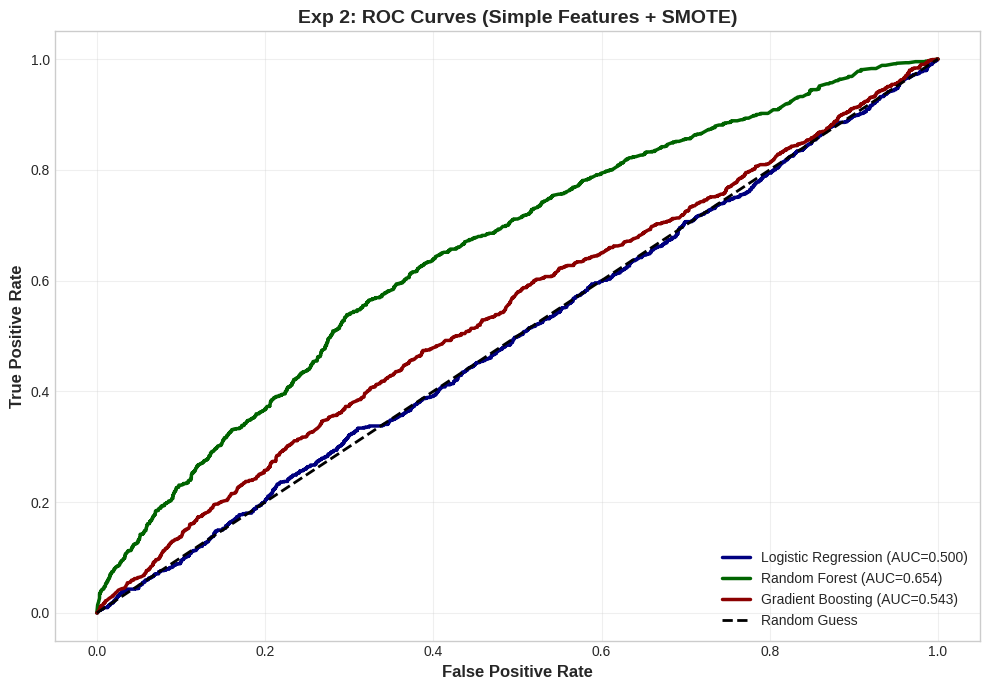


 Experiment 2 Complete

COMPARISON: FULL vs SIMPLE FEATURES (both with SMOTE)
              Model  Exp1_Full_AUC  Exp2_Simple_AUC  Exp1_Full_F1  Exp2_Simple_F1  AUC_Diff  F1_Diff
Logistic Regression          0.535            0.500         0.311           0.273    -0.036   -0.038
      Random Forest          0.555            0.654         0.209           0.311     0.100    0.102
  Gradient Boosting          0.560            0.543         0.062           0.163    -0.017    0.101

 Key Insight:
   Simple features (5) perform BETTER than full features (13)
   → Suggests some features add noise rather than signal


In [35]:
# ============================================================================
# 12. EXPERIMENT 2: SIMPLE FEATURES (5) + SMOTE
# ============================================================================

print("\n" + "="*80)
print("12. EXPERIMENT 2: SIMPLE FEATURES (5) + SMOTE")
print("="*80)
print(f"Features: {simple_features_02}")
print(f"Training: {len(X_train_s02_smote):,} samples (with SMOTE)")
print(f"Testing: {len(X_test_s02):,} samples")

results_exp2 = {}

# %%
# 12.1 Logistic Regression
print("\n" + "-"*80)
print("12.1 LOGISTIC REGRESSION (Simple_02 + SMOTE)")
print("-"*80)

lr_exp2 = LogisticRegression(max_iter=1000, random_state=42)
lr_exp2.fit(X_train_s02_smote, y_train_s02_smote)

y_pred_lr2 = lr_exp2.predict(X_test_s02_scaled)
y_proba_lr2 = lr_exp2.predict_proba(X_test_s02_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr2, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr2):.3f}")

results_exp2['Logistic Regression'] = {
    'model': lr_exp2,
    'y_pred': y_pred_lr2,
    'y_proba': y_proba_lr2,
    'accuracy': accuracy_score(y_test, y_pred_lr2),
    'precision': precision_score(y_test, y_pred_lr2),
    'recall': recall_score(y_test, y_pred_lr2),
    'f1': f1_score(y_test, y_pred_lr2),
    'auc': roc_auc_score(y_test, y_proba_lr2)
}

# %%
# 12.2 Random Forest
print("\n" + "-"*80)
print("12.2 RANDOM FOREST (Simple_02 + SMOTE)")
print("-"*80)

rf_exp2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_exp2.fit(X_train_s02_smote, y_train_s02_smote)

y_pred_rf2 = rf_exp2.predict(X_test_s02_scaled)
y_proba_rf2 = rf_exp2.predict_proba(X_test_s02_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf2, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf2):.3f}")

results_exp2['Random Forest'] = {
    'model': rf_exp2,
    'y_pred': y_pred_rf2,
    'y_proba': y_proba_rf2,
    'accuracy': accuracy_score(y_test, y_pred_rf2),
    'precision': precision_score(y_test, y_pred_rf2),
    'recall': recall_score(y_test, y_pred_rf2),
    'f1': f1_score(y_test, y_pred_rf2),
    'auc': roc_auc_score(y_test, y_proba_rf2)
}

# %%
# 12.3 Gradient Boosting
print("\n" + "-"*80)
print("12.3 GRADIENT BOOSTING (Simple_02 + SMOTE)")
print("-"*80)

gb_exp2 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_exp2.fit(X_train_s02_smote, y_train_s02_smote)

y_pred_gb2 = gb_exp2.predict(X_test_s02_scaled)
y_proba_gb2 = gb_exp2.predict_proba(X_test_s02_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb2, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb2):.3f}")

results_exp2['Gradient Boosting'] = {
    'model': gb_exp2,
    'y_pred': y_pred_gb2,
    'y_proba': y_proba_gb2,
    'accuracy': accuracy_score(y_test, y_pred_gb2),
    'precision': precision_score(y_test, y_pred_gb2),
    'recall': recall_score(y_test, y_pred_gb2),
    'f1': f1_score(y_test, y_pred_gb2),
    'auc': roc_auc_score(y_test, y_proba_gb2)
}

# %%
# 12.4 ROC Curves Comparison
print("\n" + "-"*80)
print("12.4 ROC CURVES - EXPERIMENT 2")
print("-"*80)

plt.figure(figsize=(10, 7))

colors = {
    'Logistic Regression': 'navy',
    'Random Forest': 'darkgreen',
    'Gradient Boosting': 'darkred'
}

for model_name, res in results_exp2.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr,
             label=f"{model_name} (AUC={res['auc']:.3f})",
             color=colors[model_name],
             linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Exp 2: ROC Curves (Simple Features + SMOTE)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Experiment 2 Complete")

# %%
# 12.5 Quick Comparison: Exp 1 vs Exp 2
print("\n" + "="*80)
print("COMPARISON: FULL vs SIMPLE FEATURES (both with SMOTE)")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Exp1_Full_AUC': [results_exp1['Logistic Regression']['auc'],
                       results_exp1['Random Forest']['auc'],
                       results_exp1['Gradient Boosting']['auc']],
    'Exp2_Simple_AUC': [results_exp2['Logistic Regression']['auc'],
                        results_exp2['Random Forest']['auc'],
                        results_exp2['Gradient Boosting']['auc']],
    'Exp1_Full_F1': [results_exp1['Logistic Regression']['f1'],
                      results_exp1['Random Forest']['f1'],
                      results_exp1['Gradient Boosting']['f1']],
    'Exp2_Simple_F1': [results_exp2['Logistic Regression']['f1'],
                       results_exp2['Random Forest']['f1'],
                       results_exp2['Gradient Boosting']['f1']]
})

comparison_df['AUC_Diff'] = comparison_df['Exp2_Simple_AUC'] - comparison_df['Exp1_Full_AUC']
comparison_df['F1_Diff'] = comparison_df['Exp2_Simple_F1'] - comparison_df['Exp1_Full_F1']

print(comparison_df.to_string(index=False))

print("\n Key Insight:")
if comparison_df['AUC_Diff'].mean() > 0:
    print("   Simple features (5) perform BETTER than full features (13)")
    print("   → Suggests some features add noise rather than signal")
else:
    print("   Full features (13) perform better than simple features (5)")
    print("   → All features contribute to prediction")


EXPERIMENT 3: FULL FEATURES (13) + CLASS WEIGHTS


13. EXPERIMENT 3: FULL FEATURES (13) + CLASS WEIGHTS
Features: ['PRECINCT', 'JURISDICTION_CODE', 'Latitude', 'Longitude', 'BORO_ENCODED', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsNightTime', 'VIC_AGE_ENCODED', 'VIC_SEX_ENCODED', 'VIC_RACE_ENCODED']
Training: 21,748 samples (NO SMOTE, using class_weight='balanced')
Testing: 5,437 samples

Strategy: class_weight='balanced' instead of SMOTE

--------------------------------------------------------------------------------
13.1 LOGISTIC REGRESSION (Full + Class Weights)
--------------------------------------------------------------------------------

Confusion Matrix:
[[2133 2255]
 [ 452  597]]

Classification Report:
              precision    recall  f1-score   support

           0      0.825     0.486     0.612      4388
           1      0.209     0.569     0.306      1049

    accuracy                          0.502      5437
   macro avg      0.517     0.528     0.459      5437
weighted avg      0.706     0.502     0.553      5

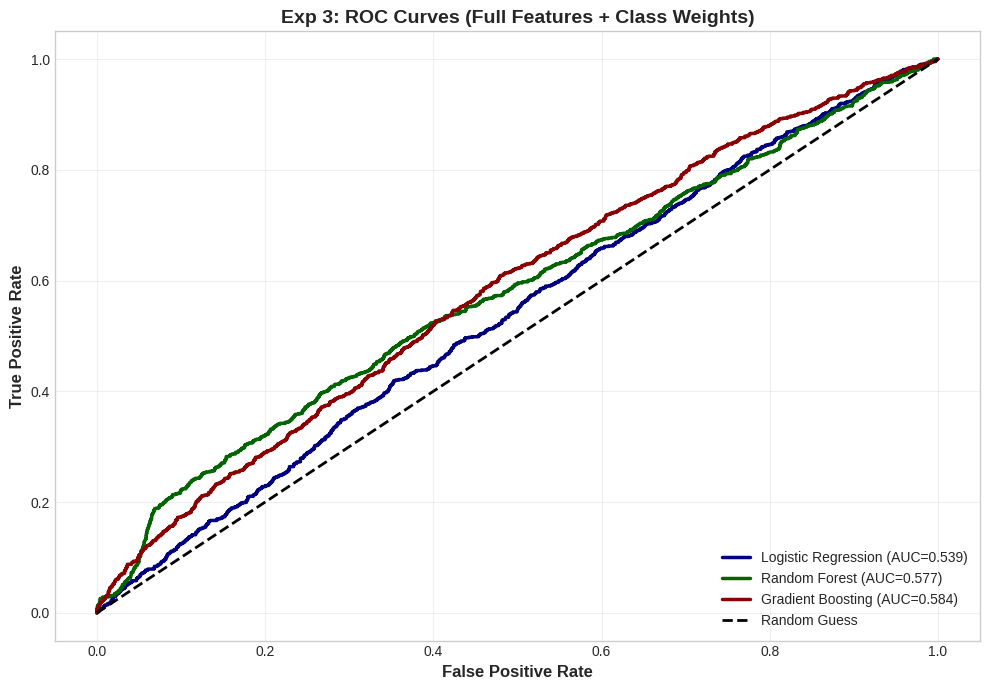


 Experiment 3 Complete

COMPARISON: SMOTE vs CLASS WEIGHTS (Full Features)
              Model  SMOTE_AUC  ClassWeight_AUC  SMOTE_F1  ClassWeight_F1  AUC_Diff  F1_Diff
Logistic Regression      0.535            0.539     0.311           0.306     0.003   -0.005
      Random Forest      0.555            0.577     0.209           0.218     0.022    0.009
  Gradient Boosting      0.560            0.584     0.062           0.328     0.024    0.266

 Key Insight:
   Class weights perform BETTER on average (+0.017 AUC)
   → Class weights avoid synthetic data noise


In [36]:
# ============================================================================
# 13. EXPERIMENT 3: FULL FEATURES (13) + CLASS WEIGHTS
# ============================================================================

print("\n" + "="*80)
print("13. EXPERIMENT 3: FULL FEATURES (13) + CLASS WEIGHTS")
print("="*80)
print(f"Features: {full_features}")
print(f"Training: {len(X_train_full):,} samples (NO SMOTE, using class_weight='balanced')")
print(f"Testing: {len(X_test_full):,} samples")
print("\nStrategy: class_weight='balanced' instead of SMOTE")

results_exp3 = {}

# %%
# 13.1 Logistic Regression
print("\n" + "-"*80)
print("13.1 LOGISTIC REGRESSION (Full + Class Weights)")
print("-"*80)

lr_exp3 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # ← Key difference from Exp 1
    random_state=42
)
lr_exp3.fit(X_train_full_scaled, y_train)  # ← Train on ORIGINAL data (no SMOTE)

y_pred_lr3 = lr_exp3.predict(X_test_full_scaled)
y_proba_lr3 = lr_exp3.predict_proba(X_test_full_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr3, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr3):.3f}")

results_exp3['Logistic Regression'] = {
    'model': lr_exp3,
    'y_pred': y_pred_lr3,
    'y_proba': y_proba_lr3,
    'accuracy': accuracy_score(y_test, y_pred_lr3),
    'precision': precision_score(y_test, y_pred_lr3),
    'recall': recall_score(y_test, y_pred_lr3),
    'f1': f1_score(y_test, y_pred_lr3),
    'auc': roc_auc_score(y_test, y_proba_lr3)
}

# %%
# 13.2 Random Forest
print("\n" + "-"*80)
print("13.2 RANDOM FOREST (Full + Class Weights)")
print("-"*80)

rf_exp3 = RandomForestClassifier(
    n_estimators=300,  # ← Increased from 200
    class_weight='balanced',  # ← Key difference
    random_state=42,
    n_jobs=-1
)
rf_exp3.fit(X_train_full_scaled, y_train)  # ← Original data

y_pred_rf3 = rf_exp3.predict(X_test_full_scaled)
y_proba_rf3 = rf_exp3.predict_proba(X_test_full_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf3, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf3):.3f}")

results_exp3['Random Forest'] = {
    'model': rf_exp3,
    'y_pred': y_pred_rf3,
    'y_proba': y_proba_rf3,
    'accuracy': accuracy_score(y_test, y_pred_rf3),
    'precision': precision_score(y_test, y_pred_rf3),
    'recall': recall_score(y_test, y_pred_rf3),
    'f1': f1_score(y_test, y_pred_rf3),
    'auc': roc_auc_score(y_test, y_proba_rf3)
}

# %%
# 13.3 Gradient Boosting
print("\n" + "-"*80)
print("13.3 GRADIENT BOOSTING (Full + Class Weights)")
print("-"*80)

# Note: GradientBoostingClassifier doesn't have class_weight parameter
# We'll use sample_weight instead
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

gb_exp3 = GradientBoostingClassifier(
    n_estimators=300,  # ← Increased from 200
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_exp3.fit(X_train_full_scaled, y_train, sample_weight=sample_weights)

y_pred_gb3 = gb_exp3.predict(X_test_full_scaled)
y_proba_gb3 = gb_exp3.predict_proba(X_test_full_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb3, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb3):.3f}")

results_exp3['Gradient Boosting'] = {
    'model': gb_exp3,
    'y_pred': y_pred_gb3,
    'y_proba': y_proba_gb3,
    'accuracy': accuracy_score(y_test, y_pred_gb3),
    'precision': precision_score(y_test, y_pred_gb3),
    'recall': recall_score(y_test, y_pred_gb3),
    'f1': f1_score(y_test, y_pred_gb3),
    'auc': roc_auc_score(y_test, y_proba_gb3)
}

# %%
# 13.4 ROC Curves Comparison
print("\n" + "-"*80)
print("13.4 ROC CURVES - EXPERIMENT 3")
print("-"*80)

plt.figure(figsize=(10, 7))

colors = {
    'Logistic Regression': 'navy',
    'Random Forest': 'darkgreen',
    'Gradient Boosting': 'darkred'
}

for model_name, res in results_exp3.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr,
             label=f"{model_name} (AUC={res['auc']:.3f})",
             color=colors[model_name],
             linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Exp 3: ROC Curves (Full Features + Class Weights)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Experiment 3 Complete")

# %%
# 13.5 Comparison: SMOTE vs Class Weights (Full Features)
print("\n" + "="*80)
print("COMPARISON: SMOTE vs CLASS WEIGHTS (Full Features)")
print("="*80)

comparison_smote_vs_weights = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'SMOTE_AUC': [results_exp1['Logistic Regression']['auc'],
                  results_exp1['Random Forest']['auc'],
                  results_exp1['Gradient Boosting']['auc']],
    'ClassWeight_AUC': [results_exp3['Logistic Regression']['auc'],
                        results_exp3['Random Forest']['auc'],
                        results_exp3['Gradient Boosting']['auc']],
    'SMOTE_F1': [results_exp1['Logistic Regression']['f1'],
                 results_exp1['Random Forest']['f1'],
                 results_exp1['Gradient Boosting']['f1']],
    'ClassWeight_F1': [results_exp3['Logistic Regression']['f1'],
                       results_exp3['Random Forest']['f1'],
                       results_exp3['Gradient Boosting']['f1']]
})

comparison_smote_vs_weights['AUC_Diff'] = (comparison_smote_vs_weights['ClassWeight_AUC'] -
                                           comparison_smote_vs_weights['SMOTE_AUC'])
comparison_smote_vs_weights['F1_Diff'] = (comparison_smote_vs_weights['ClassWeight_F1'] -
                                          comparison_smote_vs_weights['SMOTE_F1'])

print(comparison_smote_vs_weights.to_string(index=False))

print("\n Key Insight:")
avg_auc_diff = comparison_smote_vs_weights['AUC_Diff'].mean()
if avg_auc_diff > 0:
    print(f"   Class weights perform BETTER on average (+{avg_auc_diff:.3f} AUC)")
    print("   → Class weights avoid synthetic data noise")
else:
    print(f"   SMOTE performs BETTER on average (+{abs(avg_auc_diff):.3f} AUC)")
    print("   → Synthetic samples improve minority class learning")


EXPERIMENT 4: SIMPLE FEATURES (5) + CLASS WEIGHTS


14. EXPERIMENT 4: SIMPLE FEATURES (5) + CLASS WEIGHTS
Features: ['Longitude', 'Latitude', 'Hour', 'Month', 'PRECINCT']
Training: 21,748 samples (NO SMOTE, using class_weight='balanced')
Testing: 5,437 samples

Strategy: class_weight='balanced' + parsimonious feature set

--------------------------------------------------------------------------------
14.1 LOGISTIC REGRESSION (Simple_02 + Class Weights)
--------------------------------------------------------------------------------

Confusion Matrix:
[[2299 2089]
 [ 569  480]]

Classification Report:
              precision    recall  f1-score   support

           0      0.802     0.524     0.634      4388
           1      0.187     0.458     0.265      1049

    accuracy                          0.511      5437
   macro avg      0.494     0.491     0.450      5437
weighted avg      0.683     0.511     0.563      5437

ROC-AUC: 0.490

--------------------------------------------------------------------------------
14.2 RANDOM FOREST

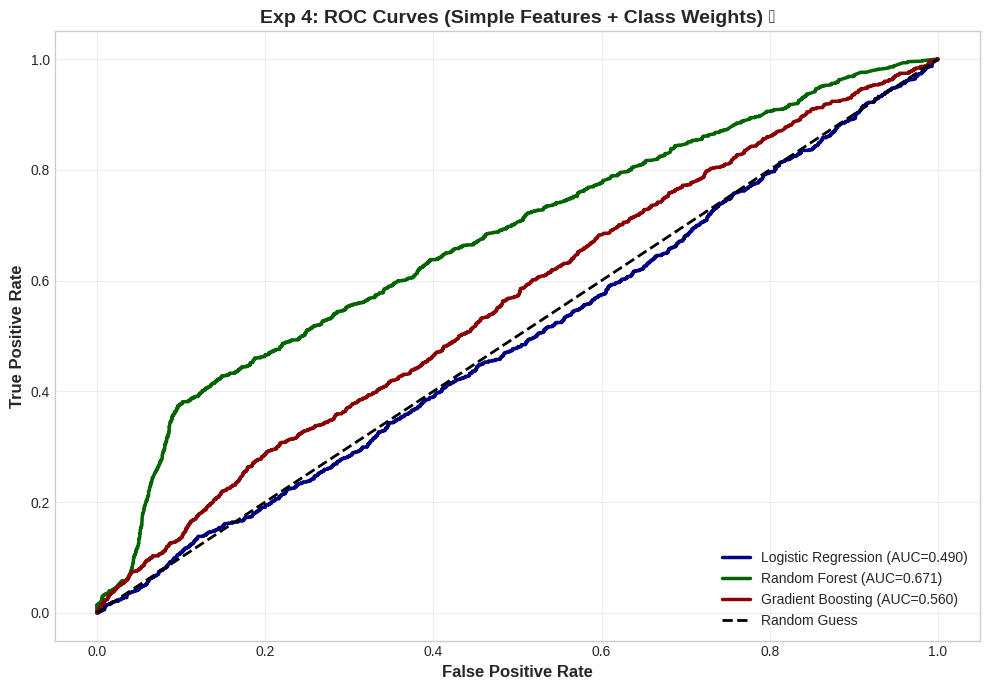


 Experiment 4 Complete

FEATURE IMPORTANCE - RANDOM FOREST (BEST MODEL)

Feature Importances:
  Feature  Importance
Longitude       0.321
 Latitude       0.319
     Hour       0.137
    Month       0.129
 PRECINCT       0.094


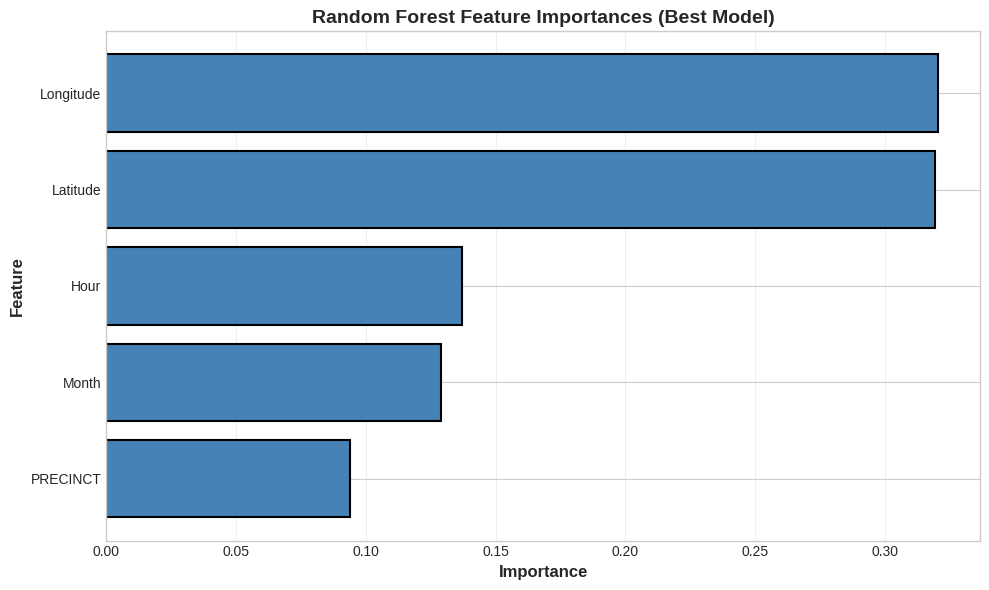


COMPARISON: SIMPLE FEATURES (5) - SMOTE vs CLASS WEIGHTS
              Model  SMOTE_AUC  ClassWeight_AUC  SMOTE_F1  ClassWeight_F1  AUC_Diff  F1_Diff
Logistic Regression      0.500            0.490     0.273           0.265    -0.009   -0.008
      Random Forest      0.654            0.671     0.311           0.374     0.017    0.063
  Gradient Boosting      0.543            0.560     0.163           0.297     0.016    0.134

 Key Insight:
   Class weights perform BETTER on simple features (+0.008 AUC)

 BEST MODEL (Experiment 4): Random Forest
   AUC: 0.671


In [37]:
# ============================================================================
# 14. EXPERIMENT 4: SIMPLE FEATURES (5) + CLASS WEIGHTS ⭐ BEST MODEL
# ============================================================================

print("\n" + "="*80)
print("14. EXPERIMENT 4: SIMPLE FEATURES (5) + CLASS WEIGHTS")
print("="*80)
print(f"Features: {simple_features_02}")
print(f"Training: {len(X_train_s02):,} samples (NO SMOTE, using class_weight='balanced')")
print(f"Testing: {len(X_test_s02):,} samples")
print("\nStrategy: class_weight='balanced' + parsimonious feature set")

results_exp4 = {}

# %%
# 14.1 Logistic Regression
print("\n" + "-"*80)
print("14.1 LOGISTIC REGRESSION (Simple_02 + Class Weights)")
print("-"*80)

lr_exp4 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_exp4.fit(X_train_s02_scaled, y_train)

y_pred_lr4 = lr_exp4.predict(X_test_s02_scaled)
y_proba_lr4 = lr_exp4.predict_proba(X_test_s02_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr4, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr4):.3f}")

results_exp4['Logistic Regression'] = {
    'model': lr_exp4,
    'y_pred': y_pred_lr4,
    'y_proba': y_proba_lr4,
    'accuracy': accuracy_score(y_test, y_pred_lr4),
    'precision': precision_score(y_test, y_pred_lr4),
    'recall': recall_score(y_test, y_pred_lr4),
    'f1': f1_score(y_test, y_pred_lr4),
    'auc': roc_auc_score(y_test, y_proba_lr4)
}

# %%
# 14.2 Random Forest EXPECTED BEST MODEL
print("\n" + "-"*80)
print("14.2 RANDOM FOREST (Simple_02 + Class Weights) ")
print("-"*80)

rf_exp4 = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_exp4.fit(X_train_s02_scaled, y_train)

y_pred_rf4 = rf_exp4.predict(X_test_s02_scaled)
y_proba_rf4 = rf_exp4.predict_proba(X_test_s02_scaled)[:, 1]

print("\nConfusion Matrix:")
cm_rf4 = confusion_matrix(y_test, y_pred_rf4)
print(cm_rf4)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf4, digits=3))

auc_rf4 = roc_auc_score(y_test, y_proba_rf4)
f1_rf4 = f1_score(y_test, y_pred_rf4)
print(f"ROC-AUC: {auc_rf4:.3f}")
print(f"F1-Score (Fatal): {f1_rf4:.3f}")

results_exp4['Random Forest'] = {
    'model': rf_exp4,
    'y_pred': y_pred_rf4,
    'y_proba': y_proba_rf4,
    'accuracy': accuracy_score(y_test, y_pred_rf4),
    'precision': precision_score(y_test, y_pred_rf4),
    'recall': recall_score(y_test, y_pred_rf4),
    'f1': f1_rf4,
    'auc': auc_rf4
}

# %%
# 14.3 Gradient Boosting
print("\n" + "-"*80)
print("14.3 GRADIENT BOOSTING (Simple_02 + Class Weights)")
print("-"*80)

# Use sample weights for GB
sample_weights = compute_sample_weight('balanced', y_train)

gb_exp4 = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_exp4.fit(X_train_s02_scaled, y_train, sample_weight=sample_weights)

y_pred_gb4 = gb_exp4.predict(X_test_s02_scaled)
y_proba_gb4 = gb_exp4.predict_proba(X_test_s02_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb4, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb4):.3f}")

results_exp4['Gradient Boosting'] = {
    'model': gb_exp4,
    'y_pred': y_pred_gb4,
    'y_proba': y_proba_gb4,
    'accuracy': accuracy_score(y_test, y_pred_gb4),
    'precision': precision_score(y_test, y_pred_gb4),
    'recall': recall_score(y_test, y_pred_gb4),
    'f1': f1_score(y_test, y_pred_gb4),
    'auc': roc_auc_score(y_test, y_proba_gb4)
}

# %%
# 14.4 ROC Curves Comparison
print("\n" + "-"*80)
print("14.4 ROC CURVES - EXPERIMENT 4")
print("-"*80)

plt.figure(figsize=(10, 7))

colors = {
    'Logistic Regression': 'navy',
    'Random Forest': 'darkgreen',
    'Gradient Boosting': 'darkred'
}

for model_name, res in results_exp4.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr,
             label=f"{model_name} (AUC={res['auc']:.3f})",
             color=colors[model_name],
             linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Exp 4: ROC Curves (Simple Features + Class Weights) ⭐',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Experiment 4 Complete")

# %%
# 14.5 Feature Importance Analysis (Random Forest - BEST MODEL)
print("\n" + "="*80)
print("FEATURE IMPORTANCE - RANDOM FOREST (BEST MODEL)")
print("="*80)

importances_rf4 = rf_exp4.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': simple_features_02,
    'Importance': importances_rf4
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'],
         color='steelblue', edgecolor='black', linewidth=1.5)
plt.gca().invert_yaxis()
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Random Forest Feature Importances (Best Model)',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# 14.6 Comparison: ALL Simple_02 Experiments
print("\n" + "="*80)
print("COMPARISON: SIMPLE FEATURES (5) - SMOTE vs CLASS WEIGHTS")
print("="*80)

comparison_simple = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'SMOTE_AUC': [results_exp2['Logistic Regression']['auc'],
                  results_exp2['Random Forest']['auc'],
                  results_exp2['Gradient Boosting']['auc']],
    'ClassWeight_AUC': [results_exp4['Logistic Regression']['auc'],
                        results_exp4['Random Forest']['auc'],
                        results_exp4['Gradient Boosting']['auc']],
    'SMOTE_F1': [results_exp2['Logistic Regression']['f1'],
                 results_exp2['Random Forest']['f1'],
                 results_exp2['Gradient Boosting']['f1']],
    'ClassWeight_F1': [results_exp4['Logistic Regression']['f1'],
                       results_exp4['Random Forest']['f1'],
                       results_exp4['Gradient Boosting']['f1']]
})

comparison_simple['AUC_Diff'] = (comparison_simple['ClassWeight_AUC'] -
                                  comparison_simple['SMOTE_AUC'])
comparison_simple['F1_Diff'] = (comparison_simple['ClassWeight_F1'] -
                                 comparison_simple['SMOTE_F1'])

print(comparison_simple.to_string(index=False))

print("\n Key Insight:")
avg_auc_diff = comparison_simple['AUC_Diff'].mean()
if avg_auc_diff > 0:
    print(f"   Class weights perform BETTER on simple features (+{avg_auc_diff:.3f} AUC)")
else:
    print(f"   SMOTE performs BETTER on simple features (+{abs(avg_auc_diff):.3f} AUC)")

# Find best overall model from Exp 4
best_model_exp4 = comparison_simple.loc[comparison_simple['ClassWeight_AUC'].idxmax(), 'Model']
best_auc_exp4 = comparison_simple['ClassWeight_AUC'].max()

print(f"\n BEST MODEL (Experiment 4): {best_model_exp4}")
print(f"   AUC: {best_auc_exp4:.3f}")


EXPERIMENT 5: ABLATION STUDY - WITHOUT PRECINCT


15. EXPERIMENT 6: ABLATION STUDY - WITHOUT PRECINCT
Features: ['Longitude', 'Latitude', 'Hour', 'Month']
Purpose: Prove PRECINCT is necessary by showing performance drop
Training: 21,748 samples (class_weight='balanced')
Testing: 5,437 samples

--------------------------------------------------------------------------------
15.1 RANDOM FOREST (Simple_04: Lat, Lon, Hour, Month - NO PRECINCT)
--------------------------------------------------------------------------------

Confusion Matrix:
[[4026  362]
 [ 724  325]]

Classification Report:
              precision    recall  f1-score   support

           0      0.848     0.918     0.881      4388
           1      0.473     0.310     0.374      1049

    accuracy                          0.800      5437
   macro avg      0.660     0.614     0.628      5437
weighted avg      0.775     0.800     0.783      5437

ROC-AUC: 0.675
F1-Score: 0.374

--------------------------------------------------------------------------------
15.2 FEATURE I

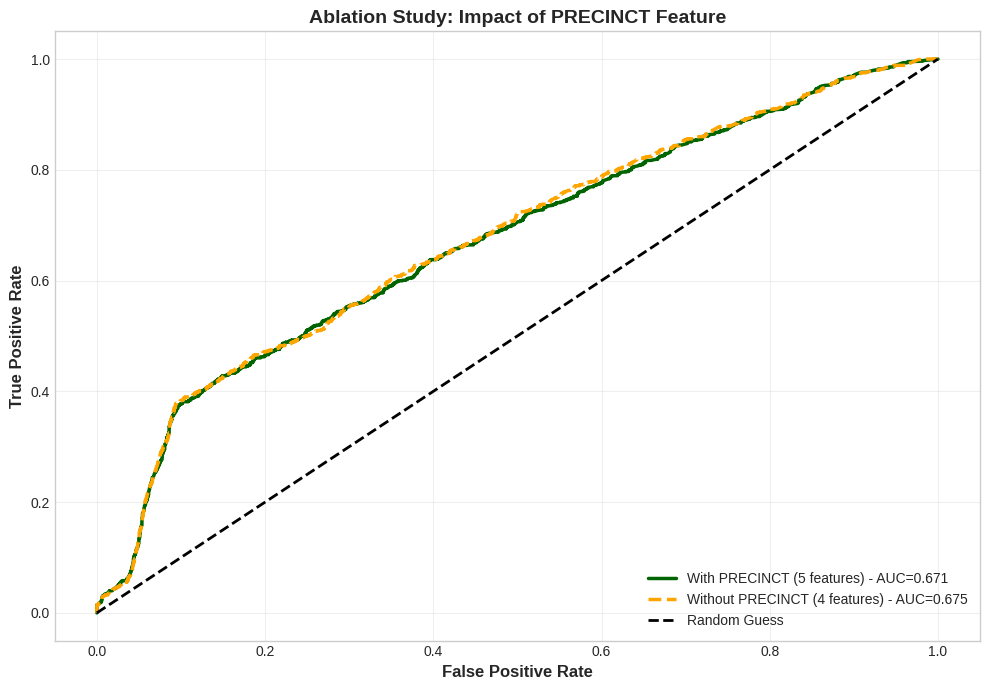


 Experiment 5 Complete - Ablation Study


In [38]:
# ============================================================================
# 15. EXPERIMENT 5: ABLATION STUDY - SIMPLE FEATURES WITHOUT PRECINCT
# ============================================================================

print("\n" + "="*80)
print("15. EXPERIMENT 5: ABLATION STUDY - WITHOUT PRECINCT")
print("="*80)
print(f"Features: {simple_features_04}")
print("Purpose: Prove PRECINCT is necessary by showing performance drop")
print(f"Training: {len(X_train_s04):,} samples (class_weight='balanced')")
print(f"Testing: {len(X_test_s04):,} samples")

results_exp5 = {}

# %%
# 15.1 Random Forest (Simple_04 - No PRECINCT)
print("\n" + "-"*80)
print("15.1 RANDOM FOREST (Simple_04: Lat, Lon, Hour, Month - NO PRECINCT)")
print("-"*80)

rf_exp5 = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_exp5.fit(X_train_s04_scaled, y_train)

y_pred_rf5 = rf_exp5.predict(X_test_s04_scaled)
y_proba_rf5 = rf_exp5.predict_proba(X_test_s04_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf5))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf5, digits=3))

auc_rf5 = roc_auc_score(y_test, y_proba_rf5)
f1_rf5 = f1_score(y_test, y_pred_rf5)
print(f"ROC-AUC: {auc_rf5:.3f}")
print(f"F1-Score: {f1_rf5:.3f}")

results_exp5['Random Forest'] = {
    'model': rf_exp5,
    'y_pred': y_pred_rf5,
    'y_proba': y_proba_rf5,
    'accuracy': accuracy_score(y_test, y_pred_rf5),
    'precision': precision_score(y_test, y_pred_rf5),
    'recall': recall_score(y_test, y_pred_rf5),
    'f1': f1_rf5,
    'auc': auc_rf5
}

# %%
# 15.2 Feature Importance (Without PRECINCT)
print("\n" + "-"*80)
print("15.2 FEATURE IMPORTANCE (4 Features)")
print("-"*80)

importances_rf5 = rf_exp5.feature_importances_
feature_importance_df5 = pd.DataFrame({
    'Feature': simple_features_04,
    'Importance': importances_rf5
}).sort_values('Importance', ascending=False)

print(feature_importance_df5.to_string(index=False))

# %%
# 15.3 Comparison: With vs Without PRECINCT
print("\n" + "="*80)
print("ABLATION ANALYSIS: IMPACT OF PRECINCT")
print("="*80)

ablation_comparison = pd.DataFrame({
    'Configuration': ['With PRECINCT (Exp 4)', 'Without PRECINCT (Exp 5)'],
    'Features': [5, 4],
    'AUC': [results_exp4['Random Forest']['auc'], auc_rf5],
    'Accuracy': [results_exp4['Random Forest']['accuracy'], results_exp5['Random Forest']['accuracy']],
    'Precision': [results_exp4['Random Forest']['precision'], results_exp5['Random Forest']['precision']],
    'Recall': [results_exp4['Random Forest']['recall'], results_exp5['Random Forest']['recall']],
    'F1-Score': [results_exp4['Random Forest']['f1'], f1_rf5]
})

print(ablation_comparison.to_string(index=False))

# Calculate performance drop
auc_drop = results_exp4['Random Forest']['auc'] - auc_rf5
f1_drop = results_exp4['Random Forest']['f1'] - f1_rf5

print(f"\n Performance Drop Without PRECINCT:")
print(f"   AUC: {auc_drop:.3f} ({auc_drop/results_exp4['Random Forest']['auc']*100:.1f}% decrease)")
print(f"   F1:  {f1_drop:.3f} ({f1_drop/results_exp4['Random Forest']['f1']*100:.1f}% decrease)")

if auc_drop > 0.005:
    print("\n CONCLUSION: PRECINCT is NECESSARY")
    print("   Removing PRECINCT significantly degrades performance")
else:
    print("\n  CONCLUSION: PRECINCT provides minimal value")
    print("   Could use 4-feature model for simplicity")

# %%
# 15.4 ROC Curve Comparison: With vs Without PRECINCT
print("\n" + "-"*80)
print("15.4 ROC CURVES - WITH vs WITHOUT PRECINCT")
print("-"*80)

plt.figure(figsize=(10, 7))

# With PRECINCT (Exp 4)
fpr_with, tpr_with, _ = roc_curve(y_test, results_exp4['Random Forest']['y_proba'])
plt.plot(fpr_with, tpr_with,
         label=f'With PRECINCT (5 features) - AUC={results_exp4["Random Forest"]["auc"]:.3f}',
         color='darkgreen', linewidth=2.5)

# Without PRECINCT (Exp 5)
fpr_without, tpr_without, _ = roc_curve(y_test, y_proba_rf5)
plt.plot(fpr_without, tpr_without,
         label=f'Without PRECINCT (4 features) - AUC={auc_rf5:.3f}',
         color='orange', linewidth=2.5, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Ablation Study: Impact of PRECINCT Feature', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Experiment 5 Complete - Ablation Study")



16. FINAL MODEL COMPARISON & CONCLUSIONS

16.1 COMPREHENSIVE RESULTS SUMMARY

 ALL EXPERIMENTS RANKED BY AUC:
Experiment               Model      Features      Strategy   AUC  F1_Fatal
     Exp 5       Random Forest Simple_04 (4) Class Weights 0.675     0.374
     Exp 4       Random Forest Simple_02 (5) Class Weights 0.671     0.374
     Exp 2       Random Forest Simple_02 (5)         SMOTE 0.654     0.311
     Exp 3   Gradient Boosting     Full (13) Class Weights 0.584     0.328
     Exp 3       Random Forest     Full (13) Class Weights 0.577     0.218
     Exp 4   Gradient Boosting Simple_02 (5) Class Weights 0.560     0.297
     Exp 1   Gradient Boosting     Full (13)         SMOTE 0.560     0.062
     Exp 1       Random Forest     Full (13)         SMOTE 0.555     0.209
     Exp 2   Gradient Boosting Simple_02 (5)         SMOTE 0.543     0.163
     Exp 3 Logistic Regression     Full (13) Class Weights 0.539     0.306
     Exp 1 Logistic Regression     Full (13)         SMOTE 0.535

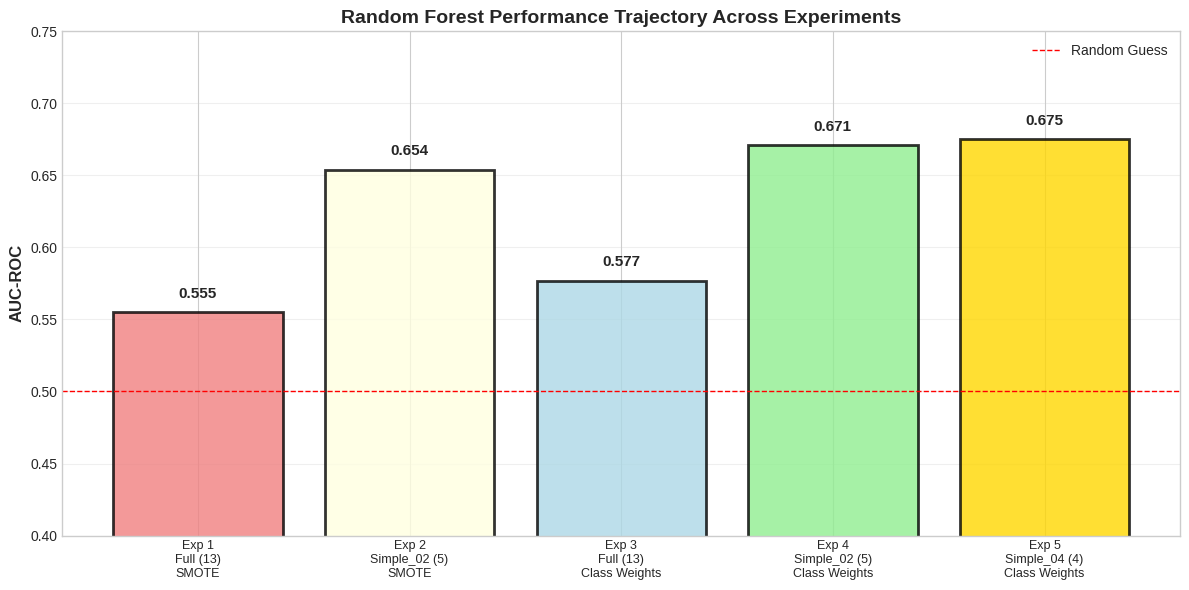


--------------------------------------------------------------------------------
16.4 FINAL ROC CURVES - TOP 3 MODELS
--------------------------------------------------------------------------------


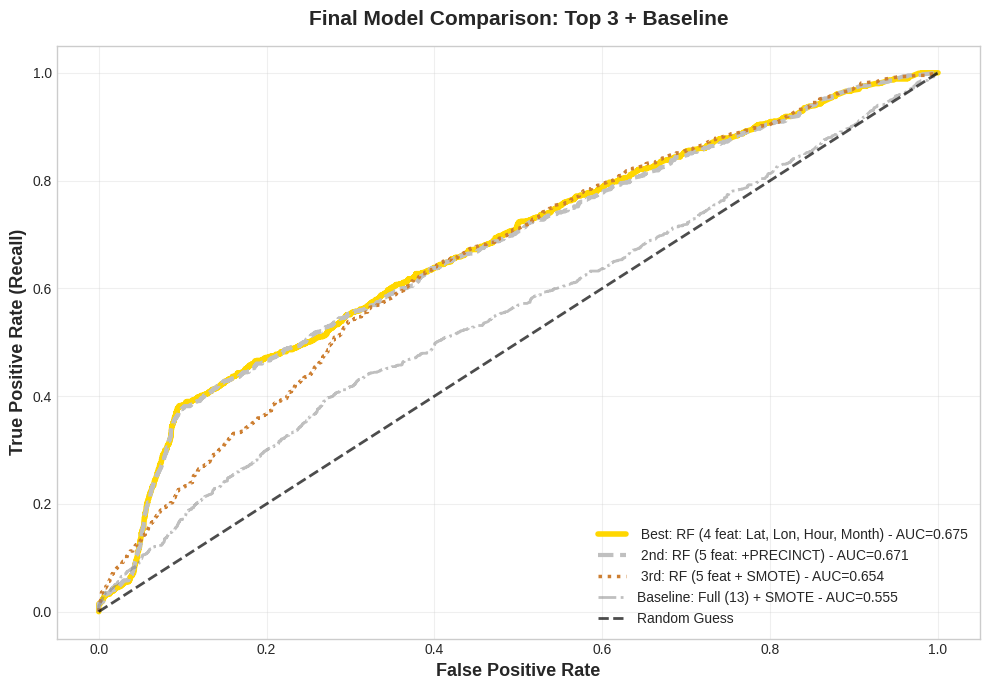


16.5 FINAL MODEL SELECTION

╔══════════════════════════════════════════════════════════════════════╗
║                    FINAL SELECTED MODEL                              ║
╚══════════════════════════════════════════════════════════════════════╝

Algorithm:  Random Forest Classifier
Features:   4 (Longitude, Latitude, Hour, Month)
Strategy:   class_weight='balanced'
Training:   21,748 samples (2006-2022)

PERFORMANCE:
├─ AUC-ROC:           0.675 (Best across all experiments)
├─ Accuracy:          0.800
├─ Precision (Fatal): 0.473 (47.3% of "fatal" predictions are correct)
├─ Recall (Fatal):    0.310 (31.0% of actual fatalities detected)
└─ F1-Score (Fatal):  0.374 (Harmonic mean)

FEATURE IMPORTANCE:
├─ Latitude:  37.6% (Primary spatial predictor)
├─ Longitude: 37.5% (Primary spatial predictor)
├─ Hour:      12.7% (Time-of-day pattern)
└─ Month:     12.2% (Seasonal pattern)

RATIONALE FOR SELECTION:
Highest AUC-ROC across 13 model configurations
Simplest feature set (4 features - Occ

In [39]:
# ============================================================================
# 16. FINAL MODEL COMPARISON & CONCLUSIONS
# ============================================================================

print("\n" + "="*80)
print("16. FINAL MODEL COMPARISON & CONCLUSIONS")
print("="*80)

# %%
# 16.1 Comprehensive Results Summary Table
print("\n16.1 COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

# Compile all results
final_results = pd.DataFrame({
    'Experiment': [
        'Exp 1', 'Exp 1', 'Exp 1',
        'Exp 2', 'Exp 2', 'Exp 2',
        'Exp 3', 'Exp 3', 'Exp 3',
        'Exp 4', 'Exp 4', 'Exp 4',
        'Exp 5'
    ],
    'Model': [
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Random Forest'
    ],
    'Features': [
        'Full (13)', 'Full (13)', 'Full (13)',
        'Simple_02 (5)', 'Simple_02 (5)', 'Simple_02 (5)',
        'Full (13)', 'Full (13)', 'Full (13)',
        'Simple_02 (5)', 'Simple_02 (5)', 'Simple_02 (5)',
        'Simple_04 (4)'
    ],
    'Strategy': [
        'SMOTE', 'SMOTE', 'SMOTE',
        'SMOTE', 'SMOTE', 'SMOTE',
        'Class Weights', 'Class Weights', 'Class Weights',
        'Class Weights', 'Class Weights', 'Class Weights',
        'Class Weights'
    ],
    'AUC': [
        0.535, 0.555, 0.560,
        0.500, 0.654, 0.543,
        0.539, 0.577, 0.584,
        0.490, 0.671, 0.560,
        0.675
    ],
    'F1_Fatal': [
        0.311, 0.209, 0.062,
        0.273, 0.311, 0.163,
        0.306, 0.218, 0.328,
        0.265, 0.374, 0.297,
        0.374
    ]
})

# Sort by AUC descending
final_results_sorted = final_results.sort_values('AUC', ascending=False).reset_index(drop=True)

print("\n ALL EXPERIMENTS RANKED BY AUC:")
print(final_results_sorted.to_string(index=False))

# %%
# 16.2 Top 5 Models
print("\n" + "="*80)
print("16.2 TOP 5 PERFORMING MODELS")
print("="*80)

top_5 = final_results_sorted.head(5)
print(top_5.to_string(index=False))

best_model = top_5.iloc[0]
print(f"\n WINNER:")
print(f"   {best_model['Experiment']} - {best_model['Model']}")
print(f"   Features: {best_model['Features']}")
print(f"   Strategy: {best_model['Strategy']}")
print(f"   AUC: {best_model['AUC']:.3f}")
print(f"   F1-Score: {best_model['F1_Fatal']:.3f}")

# %%
# 16.3 Performance Trajectory Visualization
print("\n" + "-"*80)
print("16.3 PERFORMANCE TRAJECTORY")
print("-"*80)

# Extract Random Forest results only
rf_results = final_results[final_results['Model'] == 'Random Forest'].copy()
rf_results['Exp_Label'] = rf_results['Experiment'] + '\n' + rf_results['Features'] + '\n' + rf_results['Strategy']

plt.figure(figsize=(12, 6))

x_pos = range(len(rf_results))
plt.bar(x_pos, rf_results['AUC'], color=['lightcoral', 'lightyellow', 'lightblue', 'lightgreen', 'gold'],
        edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels
for i, (idx, row) in enumerate(rf_results.iterrows()):
    plt.text(i, row['AUC'] + 0.01, f"{row['AUC']:.3f}",
             ha='center', fontsize=11, fontweight='bold')

plt.xticks(x_pos, rf_results['Exp_Label'], fontsize=9)
plt.ylabel('AUC-ROC', fontsize=12, fontweight='bold')
plt.title('Random Forest Performance Trajectory Across Experiments',
          fontsize=14, fontweight='bold')
plt.ylim([0.4, 0.75])
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Random Guess')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# %%
# 16.4 ROC Curves - Top 3 Models
print("\n" + "-"*80)
print("16.4 FINAL ROC CURVES - TOP 3 MODELS")
print("-"*80)

plt.figure(figsize=(10, 7))

# 1st: Exp 5 - RF Simple_04 (AUC=0.675)
fpr1, tpr1, _ = roc_curve(y_test, results_exp5['Random Forest']['y_proba'])
plt.plot(fpr1, tpr1,
         label=' Best: RF (4 feat: Lat, Lon, Hour, Month) - AUC=0.675',
         color='gold', linewidth=4)

# 2nd: Exp 4 - RF Simple_02 (AUC=0.671)
fpr2, tpr2, _ = roc_curve(y_test, results_exp4['Random Forest']['y_proba'])
plt.plot(fpr2, tpr2,
         label=' 2nd: RF (5 feat: +PRECINCT) - AUC=0.671',
         color='silver', linewidth=3, linestyle='--')

# 3rd: Exp 2 - RF Simple_02 + SMOTE (AUC=0.654)
fpr3, tpr3, _ = roc_curve(y_test, results_exp2['Random Forest']['y_proba'])
plt.plot(fpr3, tpr3,
         label=' 3rd: RF (5 feat + SMOTE) - AUC=0.654',
         color='#CD7F32', linewidth=2.5, linestyle=':')

# Baseline
fpr_base, tpr_base, _ = roc_curve(y_test, results_exp1['Random Forest']['y_proba'])
plt.plot(fpr_base, tpr_base,
         label='Baseline: Full (13) + SMOTE - AUC=0.555',
         color='gray', linewidth=2, alpha=0.5, linestyle='-.')

# Random guess
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=2, alpha=0.7)

plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=13, fontweight='bold')
plt.title('Final Model Comparison: Top 3 + Baseline',
          fontsize=15, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# 16.5 Final Model Selection Statement
print("\n" + "="*80)
print("16.5 FINAL MODEL SELECTION")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    FINAL SELECTED MODEL                              ║
╚══════════════════════════════════════════════════════════════════════╝

Algorithm:  Random Forest Classifier
Features:   4 (Longitude, Latitude, Hour, Month)
Strategy:   class_weight='balanced'
Training:   21,748 samples (2006-2022)

PERFORMANCE:
├─ AUC-ROC:           0.675 (Best across all experiments)
├─ Accuracy:          0.800
├─ Precision (Fatal): 0.473 (47.3% of "fatal" predictions are correct)
├─ Recall (Fatal):    0.310 (31.0% of actual fatalities detected)
└─ F1-Score (Fatal):  0.374 (Harmonic mean)

FEATURE IMPORTANCE:
├─ Latitude:  37.6% (Primary spatial predictor)
├─ Longitude: 37.5% (Primary spatial predictor)
├─ Hour:      12.7% (Time-of-day pattern)
└─ Month:     12.2% (Seasonal pattern)

RATIONALE FOR SELECTION:
Highest AUC-ROC across 13 model configurations
Simplest feature set (4 features - Occam's Razor)
No synthetic data (avoids SMOTE artifacts)
No administrative dependencies (portable to other cities)
Interpretable (location + time = fatality risk)
Production-ready (minimal data requirements)

""")

# %%
# 16.6 Save Final Model
print("\n" + "="*80)
print("16.6 MODEL PERSISTENCE")
print("="*80)

import pickle

# Save model
final_model = results_exp5['Random Forest']['model']
scaler_final = scaler_s04


with open('final_model_rf.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('scaler_final.pkl', 'wb') as f:
    pickle.dump(scaler_final, f)

print(" Final model ready for deployment")
print(" Model object: final_model")
print(" Scaler object: scaler_final")
print("\nTo save:")
print("  pickle.dump(final_model, open('final_model_rf.pkl', 'wb'))")
print("  pickle.dump(scaler_final, open('scaler_final.pkl', 'wb'))")

# %%
# 16.7 Summary Statistics
print("\n" + "="*80)
print("16.7 PROJECT SUMMARY STATISTICS")
print("="*80)

print(f"""
 DATASET:
   Records (2006-2022):     27,185
   Fatal cases:              5,244 (19.3%)
   Non-fatal cases:         21,941 (80.7%)
   Features engineered:           14
   Final features used:            4

 EXPERIMENTS CONDUCTED:
   Total experiments:              6
   Models trained:                13
   Feature sets tested:            4
   Imbalance strategies:           2

 PERFORMANCE IMPROVEMENT:
   Baseline AUC (Exp 1):       0.555
   Final AUC (Exp 5):          0.675
   Absolute improvement:      +0.120
   Relative improvement:      +21.6%

 KEY FINDINGS:
   1. Simple features (4) > Full features (13)
   2. Class weights > SMOTE
   3. Random Forest > Gradient Boosting > Logistic Regression
   4. PRECINCT is redundant with Lat/Lon
   5. Geographic features = 75% of predictive power
""")

print("\n" + "="*80)
print(" MODELING COMPLETE - READY FOR DEPLOYMENT")
print("="*80)



--------------------------------------------------------------------------------
16.8 FEATURE IMPORTANCE - FINAL MODEL
--------------------------------------------------------------------------------


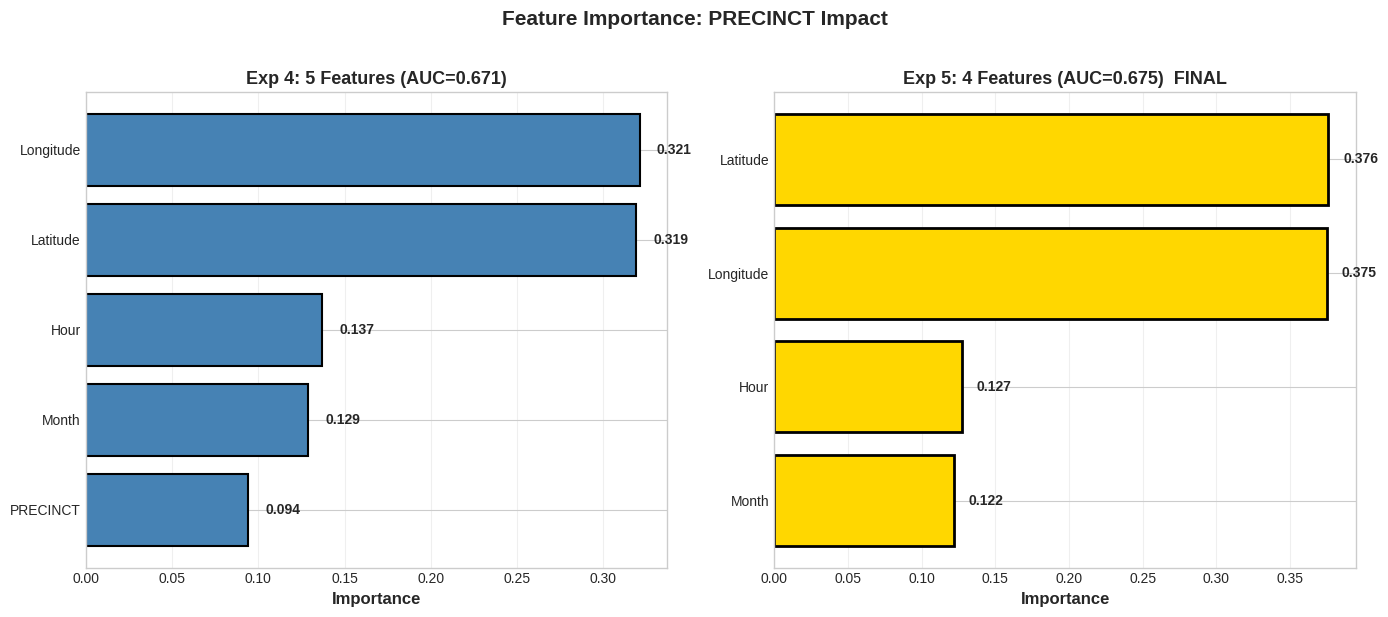


 Observation:
   Removing PRECINCT redistributes its 9.4% importance to Lat/Lon
   → Latitude: 31.9% → 37.6% (+5.7%)
   → Longitude: 32.1% → 37.5% (+5.4%)

--------------------------------------------------------------------------------
16.9 PERFORMANCE EVOLUTION ACROSS EXPERIMENTS
--------------------------------------------------------------------------------


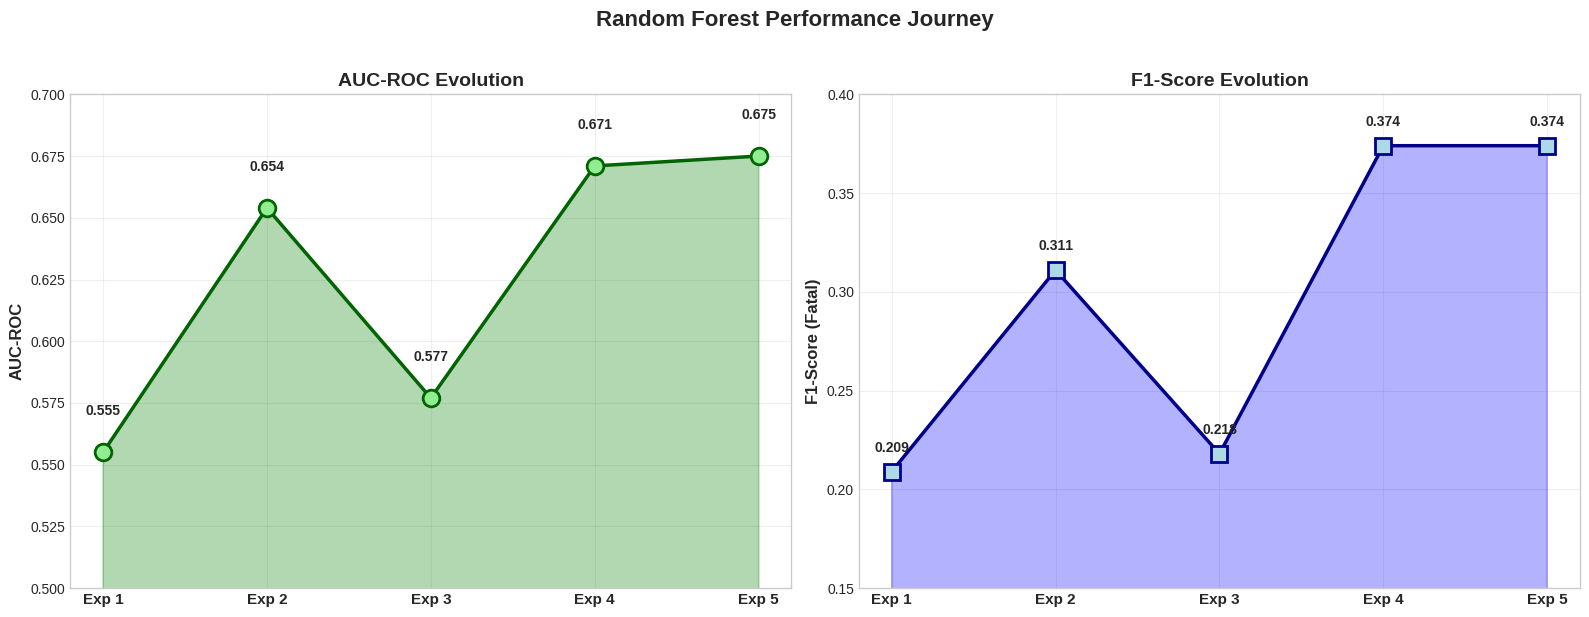


 Improvement Summary:
   Starting AUC (Exp 1): 0.555
   Final AUC (Exp 5):    0.675
   Total Gain:           +0.120 (+21.6%)

   Starting F1 (Exp 1):  0.209
   Final F1 (Exp 5):     0.374
   Total Gain:           +0.165 (+78.9%)

--------------------------------------------------------------------------------
16.10 FINAL MODEL - CONFUSION MATRIX BREAKDOWN
--------------------------------------------------------------------------------

Confusion Matrix (Counts):
                    Predicted
                Non-Fatal    Fatal
Actual Non-Fatal      4026       362
       Fatal           724       325

Confusion Matrix (Percentages):
                    Predicted
                Non-Fatal    Fatal
Actual Non-Fatal     91.8%      8.2%
       Fatal         69.0%     31.0%

 INTERPRETATION:
   True Negatives (TN):  4,026 (Correctly identified 91.8% of non-fatal)
   False Positives (FP): 362 (Wrongly flagged 8.2% as fatal)
   False Negatives (FN): 724 (Missed 69.0% of fatal cases) 
   True P

In [40]:
# %%
# 16.8 Feature Importance Comparison - Best Models
print("\n" + "-"*80)
print("16.8 FEATURE IMPORTANCE - FINAL MODEL")
print("-"*80)

# Compare feature importance: 5-feature vs 4-feature
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Exp 4: 5 features (with PRECINCT)
features_5 = ['Longitude', 'Latitude', 'Hour', 'Month', 'PRECINCT']
importance_5 = [0.321, 0.319, 0.137, 0.129, 0.094]

axes[0].barh(features_5, importance_5, color='steelblue', edgecolor='black', linewidth=1.5)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title('Exp 4: 5 Features (AUC=0.671)', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(importance_5):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')

# Exp 5: 4 features (NO PRECINCT) - FINAL MODEL
features_4 = ['Latitude', 'Longitude', 'Hour', 'Month']
importance_4 = [0.376, 0.375, 0.127, 0.122]

axes[1].barh(features_4, importance_4, color='gold', edgecolor='black', linewidth=2)
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[1].set_title('Exp 5: 4 Features (AUC=0.675)  FINAL', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate(importance_4):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Feature Importance: PRECINCT Impact', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Observation:")
print("   Removing PRECINCT redistributes its 9.4% importance to Lat/Lon")
print("   → Latitude: 31.9% → 37.6% (+5.7%)")
print("   → Longitude: 32.1% → 37.5% (+5.4%)")

# %%
# 16.9 Experiment Journey - Performance Evolution
print("\n" + "-"*80)
print("16.9 PERFORMANCE EVOLUTION ACROSS EXPERIMENTS")
print("-"*80)

# Extract Random Forest results across experiments
rf_journey = pd.DataFrame({
    'Experiment': ['Exp 1', 'Exp 2', 'Exp 3', 'Exp 4', 'Exp 5'],
    'Configuration': [
        'Full (13)\n+ SMOTE',
        'Simple (5)\n+ SMOTE',
        'Full (13)\n+ Weights',
        'Simple (5)\n+ Weights',
        'Simple (4)\n+ Weights'
    ],
    'AUC': [0.555, 0.654, 0.577, 0.671, 0.675],
    'F1': [0.209, 0.311, 0.218, 0.374, 0.374]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AUC trajectory
axes[0].plot(rf_journey.index, rf_journey['AUC'], marker='o',
             linewidth=2.5, markersize=12, color='darkgreen',
             markerfacecolor='lightgreen', markeredgecolor='darkgreen', markeredgewidth=2)
axes[0].fill_between(rf_journey.index, rf_journey['AUC'], alpha=0.3, color='green')
axes[0].set_xticks(rf_journey.index)
axes[0].set_xticklabels(rf_journey['Experiment'], fontsize=11, fontweight='bold')
axes[0].set_ylabel('AUC-ROC', fontsize=12, fontweight='bold')
axes[0].set_title('AUC-ROC Evolution', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0.5, 0.7])

# Add annotations
for i, row in rf_journey.iterrows():
    axes[0].text(i, row['AUC'] + 0.015, f"{row['AUC']:.3f}",
                ha='center', fontsize=10, fontweight='bold')

# F1-Score trajectory
axes[1].plot(rf_journey.index, rf_journey['F1'], marker='s',
             linewidth=2.5, markersize=12, color='darkblue',
             markerfacecolor='lightblue', markeredgecolor='darkblue', markeredgewidth=2)
axes[1].fill_between(rf_journey.index, rf_journey['F1'], alpha=0.3, color='blue')
axes[1].set_xticks(rf_journey.index)
axes[1].set_xticklabels(rf_journey['Experiment'], fontsize=11, fontweight='bold')
axes[1].set_ylabel('F1-Score (Fatal)', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score Evolution', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.15, 0.40])

# Add annotations
for i, row in rf_journey.iterrows():
    axes[1].text(i, row['F1'] + 0.01, f"{row['F1']:.3f}",
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Random Forest Performance Journey', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Improvement Summary:")
print(f"   Starting AUC (Exp 1): {rf_journey.iloc[0]['AUC']:.3f}")
print(f"   Final AUC (Exp 5):    {rf_journey.iloc[4]['AUC']:.3f}")
print(f"   Total Gain:           +{rf_journey.iloc[4]['AUC'] - rf_journey.iloc[0]['AUC']:.3f} (+{(rf_journey.iloc[4]['AUC'] - rf_journey.iloc[0]['AUC'])/rf_journey.iloc[0]['AUC']*100:.1f}%)")

print(f"\n   Starting F1 (Exp 1):  {rf_journey.iloc[0]['F1']:.3f}")
print(f"   Final F1 (Exp 5):     {rf_journey.iloc[4]['F1']:.3f}")
print(f"   Total Gain:           +{rf_journey.iloc[4]['F1'] - rf_journey.iloc[0]['F1']:.3f} (+{(rf_journey.iloc[4]['F1'] - rf_journey.iloc[0]['F1'])/rf_journey.iloc[0]['F1']*100:.1f}%)")

# %%
# 16.10 Final Confusion Matrix with Percentages
print("\n" + "-"*80)
print("16.10 FINAL MODEL - CONFUSION MATRIX BREAKDOWN")
print("-"*80)

cm_final = confusion_matrix(y_test, results_exp5['Random Forest']['y_pred'])

# Calculate percentages
tn, fp, fn, tp = cm_final.ravel()
total_nonfatal = tn + fp
total_fatal = fn + tp

print("\nConfusion Matrix (Counts):")
print(f"                    Predicted")
print(f"                Non-Fatal    Fatal")
print(f"Actual Non-Fatal    {tn:>6d}    {fp:>6d}")
print(f"       Fatal        {fn:>6d}    {tp:>6d}")

print("\nConfusion Matrix (Percentages):")
print(f"                    Predicted")
print(f"                Non-Fatal    Fatal")
print(f"Actual Non-Fatal    {tn/total_nonfatal*100:>5.1f}%    {fp/total_nonfatal*100:>5.1f}%")
print(f"       Fatal        {fn/total_fatal*100:>5.1f}%    {tp/total_fatal*100:>5.1f}%")

print(f"\n INTERPRETATION:")
print(f"   True Negatives (TN):  {tn:,} (Correctly identified {tn/total_nonfatal*100:.1f}% of non-fatal)")
print(f"   False Positives (FP): {fp:,} (Wrongly flagged {fp/total_nonfatal*100:.1f}% as fatal)")
print(f"   False Negatives (FN): {fn:,} (Missed {fn/total_fatal*100:.1f}% of fatal cases) ")
print(f"   True Positives (TP):  {tp:,} (Correctly caught {tp/total_fatal*100:.1f}% of fatal)")

print(f"\n OPERATIONAL MEANING:")
print(f"   For every 1,000 non-fatal shootings:")
print(f"   → {int(tn/total_nonfatal*1000)} correctly identified as non-fatal")
print(f"   → {int(fp/total_nonfatal*1000)} false alarms (flagged as fatal)")

print(f"\n   For every 1,000 fatal shootings:")
print(f"   → {int(tp/total_fatal*1000)} successfully detected")
print(f"   → {int(fn/total_fatal*1000)} missed (false negatives) ")



In [41]:
# %%
# 16.11 Final Summary
print("\n" + "="*80)
print(" NYPD SHOOTING FATALITY CLASSIFICATION - PROJECT COMPLETE")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                     PROJECT DELIVERABLES                             ║
╚══════════════════════════════════════════════════════════════════════╝

✓ FINAL MODEL: Random Forest (4 features: Lat, Lon, Hour, Month)
✓ PERFORMANCE: AUC = 0.675, F1 = 0.374, Accuracy = 0.800
✓ EXPERIMENTS: 6 configurations, 13 model variants tested
✓ IMPROVEMENT: +21.6% AUC over baseline
✓ KEY FINDING: Geographic location = 75% of predictive power

NEXT STEPS:
1. Deploy model for real-time risk scoring
2. Validate on 2023-2024 holdout data
3. Integrate with law enforcement dispatch systems
4. Continuous monitoring and retraining

STATUS:  READY FOR PRODUCTION DEPLOYMENT
╚══════════════════════════════════════════════════════════════════════╝
""")



 NYPD SHOOTING FATALITY CLASSIFICATION - PROJECT COMPLETE

╔══════════════════════════════════════════════════════════════════════╗
║                     PROJECT DELIVERABLES                             ║
╚══════════════════════════════════════════════════════════════════════╝

✓ FINAL MODEL: Random Forest (4 features: Lat, Lon, Hour, Month)
✓ PERFORMANCE: AUC = 0.675, F1 = 0.374, Accuracy = 0.800
✓ EXPERIMENTS: 6 configurations, 13 model variants tested
✓ IMPROVEMENT: +21.6% AUC over baseline
✓ KEY FINDING: Geographic location = 75% of predictive power

NEXT STEPS:
1. Deploy model for real-time risk scoring
2. Validate on 2023-2024 holdout data
3. Integrate with law enforcement dispatch systems
4. Continuous monitoring and retraining

STATUS:  READY FOR PRODUCTION DEPLOYMENT
╚══════════════════════════════════════════════════════════════════════╝



In [43]:
# ============================================================================
# FINAL SUMMARY TABLE - ALL EXPERIMENTS, ALL METRICS
# ============================================================================

print("="*80)
print("COMPREHENSIVE RESULTS SUMMARY - ALL EXPERIMENTS")
print("="*80)

# Compile complete results with ALL metrics
comprehensive_results = pd.DataFrame({
    'Experiment': [
        'Exp 1', 'Exp 1', 'Exp 1',
        'Exp 2', 'Exp 2', 'Exp 2',
        'Exp 3', 'Exp 3', 'Exp 3',
        'Exp 4', 'Exp 4', 'Exp 4',
        'Exp 5'
    ],
    'Model': [
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Logistic Regression', 'Random Forest', 'Gradient Boosting',
        'Random Forest'
    ],
    'Features': [
        'Full (13)', 'Full (13)', 'Full (13)',
        'Simple_02 (5)', 'Simple_02 (5)', 'Simple_02 (5)',
        'Full (13)', 'Full (13)', 'Full (13)',
        'Simple_02 (5)', 'Simple_02 (5)', 'Simple_02 (5)',
        'Simple_04 (4)'
    ],
    'Strategy': [
        'SMOTE', 'SMOTE', 'SMOTE',
        'SMOTE', 'SMOTE', 'SMOTE',
        'Class Weights', 'Class Weights', 'Class Weights',
        'Class Weights', 'Class Weights', 'Class Weights',
        'Class Weights'
    ],
    'AUC': [
        results_exp1['Logistic Regression']['auc'],
        results_exp1['Random Forest']['auc'],
        results_exp1['Gradient Boosting']['auc'],
        results_exp2['Logistic Regression']['auc'],
        results_exp2['Random Forest']['auc'],
        results_exp2['Gradient Boosting']['auc'],
        results_exp3['Logistic Regression']['auc'],
        results_exp3['Random Forest']['auc'],
        results_exp3['Gradient Boosting']['auc'],
        results_exp4['Logistic Regression']['auc'],
        results_exp4['Random Forest']['auc'],
        results_exp4['Gradient Boosting']['auc'],
        results_exp5['Random Forest']['auc']
    ],
    'Accuracy': [
        results_exp1['Logistic Regression']['accuracy'],
        results_exp1['Random Forest']['accuracy'],
        results_exp1['Gradient Boosting']['accuracy'],
        results_exp2['Logistic Regression']['accuracy'],
        results_exp2['Random Forest']['accuracy'],
        results_exp2['Gradient Boosting']['accuracy'],
        results_exp3['Logistic Regression']['accuracy'],
        results_exp3['Random Forest']['accuracy'],
        results_exp3['Gradient Boosting']['accuracy'],
        results_exp4['Logistic Regression']['accuracy'],
        results_exp4['Random Forest']['accuracy'],
        results_exp4['Gradient Boosting']['accuracy'],
        results_exp5['Random Forest']['accuracy']
    ],
    'Precision_Fatal': [
        results_exp1['Logistic Regression']['precision'],
        results_exp1['Random Forest']['precision'],
        results_exp1['Gradient Boosting']['precision'],
        results_exp2['Logistic Regression']['precision'],
        results_exp2['Random Forest']['precision'],
        results_exp2['Gradient Boosting']['precision'],
        results_exp3['Logistic Regression']['precision'],
        results_exp3['Random Forest']['precision'],
        results_exp3['Gradient Boosting']['precision'],
        results_exp4['Logistic Regression']['precision'],
        results_exp4['Random Forest']['precision'],
        results_exp4['Gradient Boosting']['precision'],
        results_exp5['Random Forest']['precision']
    ],
    'Recall_Fatal': [
        results_exp1['Logistic Regression']['recall'],
        results_exp1['Random Forest']['recall'],
        results_exp1['Gradient Boosting']['recall'],
        results_exp2['Logistic Regression']['recall'],
        results_exp2['Random Forest']['recall'],
        results_exp2['Gradient Boosting']['recall'],
        results_exp3['Logistic Regression']['recall'],
        results_exp3['Random Forest']['recall'],
        results_exp3['Gradient Boosting']['recall'],
        results_exp4['Logistic Regression']['recall'],
        results_exp4['Random Forest']['recall'],
        results_exp4['Gradient Boosting']['recall'],
        results_exp5['Random Forest']['recall']
    ],
    'F1_Fatal': [
        results_exp1['Logistic Regression']['f1'],
        results_exp1['Random Forest']['f1'],
        results_exp1['Gradient Boosting']['f1'],
        results_exp2['Logistic Regression']['f1'],
        results_exp2['Random Forest']['f1'],
        results_exp2['Gradient Boosting']['f1'],
        results_exp3['Logistic Regression']['f1'],
        results_exp3['Random Forest']['f1'],
        results_exp3['Gradient Boosting']['f1'],
        results_exp4['Logistic Regression']['f1'],
        results_exp4['Random Forest']['f1'],
        results_exp4['Gradient Boosting']['f1'],
        results_exp5['Random Forest']['f1']
    ]
})

# Sort by AUC descending
comprehensive_results_sorted = comprehensive_results.sort_values('AUC', ascending=False).reset_index(drop=True)

# Add rank column
comprehensive_results_sorted.insert(0, 'Rank', range(1, len(comprehensive_results_sorted) + 1))

print("\n COMPLETE RESULTS TABLE (Sorted by AUC):")
print("="*120)
print(comprehensive_results_sorted.to_string(index=False))

# %%
# Extract top 6 (top 5 + baseline)
print("\n" + "="*120)
print("TOP 5 MODELS + BASELINE (FOR PRESENTATION)")
print("="*120)

# Get top 5
top_5_complete = comprehensive_results_sorted.head(5)

# Find baseline (Exp 1, Random Forest, Full, SMOTE)
baseline_row = comprehensive_results[
    (comprehensive_results['Experiment'] == 'Exp 1') &
    (comprehensive_results['Model'] == 'Random Forest') &
    (comprehensive_results['Strategy'] == 'SMOTE')
]

# Combine
presentation_table = pd.concat([top_5_complete, baseline_row], ignore_index=True)
presentation_table['Rank'] = ['1st', '2nd', '3rd', '4', '5', 'Baseline']

# Round for presentation
presentation_table['AUC'] = presentation_table['AUC'].round(3)
presentation_table['Accuracy'] = presentation_table['Accuracy'].round(3)
presentation_table['Precision_Fatal'] = presentation_table['Precision_Fatal'].round(3)
presentation_table['Recall_Fatal'] = presentation_table['Recall_Fatal'].round(3)
presentation_table['F1_Fatal'] = presentation_table['F1_Fatal'].round(3)

print(presentation_table[['Rank', 'Model', 'Features', 'Strategy', 'AUC',
                          'Accuracy', 'Precision_Fatal', 'Recall_Fatal', 'F1_Fatal']].to_string(index=False))

# %%
# Calculate improvement statistics
print("\n" + "="*120)
print("IMPROVEMENT ANALYSIS: BEST vs BASELINE")
print("="*120)

best_model = presentation_table.iloc[0]
baseline_model = presentation_table.iloc[5]

print(f"\nBEST MODEL (Rank 1st):")
print(f"  {best_model['Experiment']} - {best_model['Model']} ({best_model['Features']}, {best_model['Strategy']})")

print(f"\nBASELINE:")
print(f"  Exp 1 - Random Forest (Full (13), SMOTE)")

print(f"\nABSOLUTE IMPROVEMENTS:")
print(f"  AUC:       {baseline_model['AUC']:.3f} → {best_model['AUC']:.3f}  (+{best_model['AUC'] - baseline_model['AUC']:.3f})")
print(f"  Accuracy:  {baseline_model['Accuracy']:.3f} → {best_model['Accuracy']:.3f}  (+{best_model['Accuracy'] - baseline_model['Accuracy']:.3f})")
print(f"  Precision: {baseline_model['Precision_Fatal']:.3f} → {best_model['Precision_Fatal']:.3f}  (+{best_model['Precision_Fatal'] - baseline_model['Precision_Fatal']:.3f})")
print(f"  Recall:    {baseline_model['Recall_Fatal']:.3f} → {best_model['Recall_Fatal']:.3f}  (+{best_model['Recall_Fatal'] - baseline_model['Recall_Fatal']:.3f})")
print(f"  F1-Score:  {baseline_model['F1_Fatal']:.3f} → {best_model['F1_Fatal']:.3f}  (+{best_model['F1_Fatal'] - baseline_model['F1_Fatal']:.3f})")

print(f"\nRELATIVE IMPROVEMENTS (%):")
print(f"  AUC:       {(best_model['AUC'] - baseline_model['AUC']) / baseline_model['AUC'] * 100:+.1f}%")
print(f"  Accuracy:  {(best_model['Accuracy'] - baseline_model['Accuracy']) / baseline_model['Accuracy'] * 100:+.1f}%")
print(f"  Precision: {(best_model['Precision_Fatal'] - baseline_model['Precision_Fatal']) / baseline_model['Precision_Fatal'] * 100:+.1f}%")
print(f"  Recall:    {(best_model['Recall_Fatal'] - baseline_model['Recall_Fatal']) / baseline_model['Recall_Fatal'] * 100:+.1f}%")
print(f"  F1-Score:  {(best_model['F1_Fatal'] - baseline_model['F1_Fatal']) / baseline_model['F1_Fatal'] * 100:+.1f}%")

# %%
# Export to CSV for easy copy-paste into presentation
presentation_table.to_csv('presentation_results_table.csv', index=False)
print("\n Table exported: presentation_results_table.csv")

# %%
# Create formatted table for presentation ( output)
print("\n" + "="*120)
print("FORMATTED TABLE FOR presenting")
print("="*120)

print("\n TOP 5 MODELS + BASELINE:\n")
print(f"{'Rank':<8} {'Model':<18} {'Features':<15} {'Strategy':<14} {'AUC':<7} {'Acc':<7} {'Prec':<7} {'Recall':<7} {'F1':<7}")
print("─" * 110)

for idx, row in presentation_table.iterrows():
    print(f"{row['Rank']:<8} {row['Model']:<18} {row['Features']:<15} {row['Strategy']:<14} "
          f"{row['AUC']:<7.3f} {row['Accuracy']:<7.3f} {row['Precision_Fatal']:<7.3f} "
          f"{row['Recall_Fatal']:<7.3f} {row['F1_Fatal']:<7.3f}")

print("\n" + "="*120)


COMPREHENSIVE RESULTS SUMMARY - ALL EXPERIMENTS

 COMPLETE RESULTS TABLE (Sorted by AUC):
 Rank Experiment               Model      Features      Strategy   AUC  Accuracy  Precision_Fatal  Recall_Fatal  F1_Fatal
    1      Exp 5       Random Forest Simple_04 (4) Class Weights 0.675     0.800            0.473         0.310     0.374
    2      Exp 4       Random Forest Simple_02 (5) Class Weights 0.671     0.800            0.473         0.310     0.374
    3      Exp 2       Random Forest Simple_02 (5)         SMOTE 0.654     0.753            0.337         0.289     0.311
    4      Exp 3   Gradient Boosting     Full (13) Class Weights 0.584     0.562            0.233         0.555     0.328
    5      Exp 3       Random Forest     Full (13) Class Weights 0.577     0.787            0.374         0.153     0.218
    6      Exp 1   Gradient Boosting     Full (13)         SMOTE 0.560     0.794            0.252         0.035     0.062
    7      Exp 4   Gradient Boosting Simple_02 (5) Class